## Notebook Index <a id="notebook-index"></a>

- [Topic Distribution Tests](#topic-distribution-tests)
- [Comparison Write-Ups and Figures](#comparison-writeups-and-figures)
- [Topic Sentiment Statistical Tests](#topic-sentiment-statistical-tests)

## Statistical Tests for Topic Distribution by Trait <a id="topic-distribution-tests"></a>
This notebook rebuilds review-level traits from the `Main_Full_Pipeline` inputs and produces:

1. Table 1: unique review-topic mention counts by `Location`, `Season`, and `Customer Type`
2. Table 2: the corresponding percentages of reviews in each trait, with two-proportions z-test significance markers
3. Chi-square goodness-of-fit tests by trait
4. Wilcoxon signed-rank tests comparing each trait to all other traits in the same characteristic
5. A full long-form export of the two-proportions z-tests
6. Comparison-ready figures for `Location`, `Season`, and `Customer Type`
7. Markdown-ready comparison write-ups, following the framing used in Sections 4.4.1 and 4.4.2 of Sutherland et al. (2020)

### What the Wilcoxon signed-rank test is doing here
For each trait, the paired observations are the 10 major topics, not the individual reviews. The notebook first calculates the proportion of reviews in that trait that mention each topic, then calculates the corresponding proportion for the pooled set of all other traits within the same characteristic. For example, for `London`, it compares the 10 topic proportions in `London` reviews with the 10 topic proportions in all non-`London` reviews.

The null hypothesis is that the median paired difference between those two topic-proportion vectors is zero. In plain terms, the test asks whether the trait's topic profile is systematically shifted up or down relative to the pooled remainder, rather than whether any one single topic is different on its own.

The test works by taking the topic-level differences, dropping any exact zeros, ranking the remaining differences by absolute size, restoring the sign of each original difference, and then checking whether the positive and negative ranks balance as they would under the null. A small two-sided p-value means the trait tends to have consistently larger or smaller topic proportions across the topic set than the pooled comparison group.

Interpretation note: in this notebook the Wilcoxon test is a compact summary of overall topic-profile shift across the 10 topics. It does not replace the per-topic two-proportions z-tests, and its effective paired sample size is the number of topics contributing non-zero differences.

Customer Type uses the same four traveller buckets already defined in `tagsSplit.py`: `Couple`, `Solo traveler`, `Family with young children`, and `Group`.

In [18]:
from pathlib import Path
import ast
import inspect

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from scipy.stats import chisquare, norm, wilcoxon

ZERO_SHOT_MAJOR_TOPICS = [
    "Staff Service",
    "Room Comfort & Quality",
    "Cleanliness",
    "Location & Accessibility",
    "Breakfast & Food",
    "Bathroom & Shower Experience",
    "Noise & Sleep Disturbance",
    "Facilities & Amenities",
    "Value for Money",
    "Maintenance & Room Condition",
]

CITY_ORDER = ["Amsterdam", "Barcelona", "London", "Milan", "Paris", "Vienna"]
SEASON_ORDER = ["Winter", "Spring", "Summer", "Autumn"]
TRAVELER_TYPE_ORDER = [
    "Couple",
    "Solo traveler",
    "Family with young children",
    "Group",
]

CHARACTERISTIC_SPECS = {
    "Location": {"column": "City", "traits": CITY_ORDER},
    "Season": {"column": "Season", "traits": SEASON_ORDER},
    "Customer Type": {"column": "TravelerType", "traits": TRAVELER_TYPE_ORDER},
}

def collapse_single_value(series):
    values = pd.unique(series.dropna())
    if len(values) == 0:
        return pd.NA
    if len(values) > 1:
        raise ValueError(
            f"Expected one non-null value per review in '{series.name}', found {values.tolist()}"
        )
    return values[0]

def extract_city(address):
    if not isinstance(address, str):
        return pd.NA
    address_lower = address.lower()
    for city in CITY_ORDER:
        if city.lower() in address_lower:
            return city
    if "netherlands" in address_lower:
        return "Amsterdam"
    if "spain" in address_lower:
        return "Barcelona"
    if "united kingdom" in address_lower:
        return "London"
    if "italy" in address_lower:
        return "Milan"
    if "france" in address_lower:
        return "Paris"
    if "austria" in address_lower:
        return "Vienna"
    return pd.NA

def assign_season(month):
    if pd.isna(month):
        return pd.NA
    month = int(month)
    if month in (12, 1, 2):
        return "Winter"
    if month in (3, 4, 5):
        return "Spring"
    if month in (6, 7, 8):
        return "Summer"
    return "Autumn"

def extract_traveler_type(tags_str):
    if not isinstance(tags_str, str) or not tags_str.strip():
        return pd.NA
    try:
        tags_list = ast.literal_eval(tags_str)
    except (SyntaxError, ValueError):
        return pd.NA
    tags_lower = [str(tag).strip().lower() for tag in tags_list]
    if any("couple" in tag for tag in tags_lower):
        return "Couple"
    if any("solo" in tag or "single" in tag for tag in tags_lower):
        return "Solo traveler"
    if any("family" in tag or "child" in tag or "kid" in tag for tag in tags_lower):
        return "Family with young children"
    if any("group" in tag or "friend" in tag for tag in tags_lower):
        return "Group"
    return pd.NA

def significance_symbol(p_value):
    if pd.isna(p_value):
        return ""
    if p_value <= 0.001:
        return "***"
    if p_value <= 0.01:
        return "**"
    if p_value <= 0.05:
        return "*"
    if p_value <= 0.10:
        return "()"
    return ""

def two_proportion_z_test(x1, n1, x2, n2):
    if min(n1, n2) == 0:
        return np.nan, np.nan
    pooled = (x1 + x2) / (n1 + n2)
    if pooled in (0, 1):
        return 0.0, 1.0
    se = np.sqrt(pooled * (1 - pooled) * ((1 / n1) + (1 / n2)))
    if se == 0:
        return 0.0, 1.0
    p1 = x1 / n1
    p2 = x2 / n2
    z_stat = (p1 - p2) / se
    p_value = 2 * norm.sf(abs(z_stat))
    return z_stat, p_value

def build_trait_tables(review_level, topic_mentions, trait_col, trait_order):
    review_totals = (
        review_level[["Person_id", trait_col]]
        .dropna(subset=[trait_col])
        .drop_duplicates(subset=["Person_id"])
        .groupby(trait_col)["Person_id"]
        .nunique()
        .reindex(trait_order, fill_value=0)
        .astype(int)
    )

    counts = (
        topic_mentions[["Person_id", "Semantic_Label", trait_col]]
        .dropna(subset=[trait_col])
        .drop_duplicates()
        .groupby(["Semantic_Label", trait_col])["Person_id"]
        .nunique()
        .unstack(fill_value=0)
        .reindex(index=ZERO_SHOT_MAJOR_TOPICS, columns=trait_order, fill_value=0)
        .astype(int)
    )

    proportions = counts.divide(review_totals.replace(0, np.nan), axis=1).fillna(0.0)
    percentages = proportions * 100
    return review_totals, counts, proportions, percentages

def run_chi_square_tests(counts):
    rows = []
    for trait in counts.columns:
        observed = counts[trait].astype(float)
        total = observed.sum()
        if total == 0:
            chi2_stat, p_value = np.nan, np.nan
        else:
            expected = np.repeat(total / len(observed), len(observed))
            chi2_stat, p_value = chisquare(f_obs=observed, f_exp=expected)
        rows.append(
            {
                "Trait": trait,
                "Total_Topic_Mentions": int(total),
                "Chi2_Statistic": chi2_stat,
                "Degrees_of_Freedom": len(observed) - 1,
                "P_Value": p_value,
                "Significance": significance_symbol(p_value),
            }
        )
    return pd.DataFrame(rows)

def wilcoxon_compat(x, y):
    params = inspect.signature(wilcoxon).parameters
    kwargs = {}
    if "zero_method" in params:
        kwargs["zero_method"] = "wilcox"
    if "alternative" in params:
        kwargs["alternative"] = "two-sided"
    if "method" in params:
        kwargs["method"] = "auto"
    elif "mode" in params:
        kwargs["mode"] = "auto"
    return wilcoxon(x, y, **kwargs)

def run_wilcoxon_tests(counts, review_totals):
    """Compare one trait's topic-proportion profile with the pooled remainder.

    Each Wilcoxon test uses the topics as paired observations: for every topic,
    compare the share of reviews mentioning that topic within the focal trait
    against the share in all other traits in the same characteristic. The
    two-sided null is that the median paired difference across topics is zero,
    meaning there is no systematic overall shift in topic prominence.
    """
    rows = []
    total_reviews = int(review_totals.sum())
    for trait in counts.columns:
        n_trait = int(review_totals[trait])
        n_other = total_reviews - n_trait
        trait_props = counts[trait] / n_trait if n_trait else pd.Series(np.nan, index=counts.index)
        other_counts = counts.drop(columns=[trait]).sum(axis=1)
        other_props = other_counts / n_other if n_other else pd.Series(np.nan, index=counts.index)
        diffs = (trait_props - other_props).dropna()
        # SciPy ranks the absolute non-zero paired differences internally and
        # tests whether positive and negative ranks are balanced around zero.
        non_zero = diffs[diffs != 0]
        stat, p_value = np.nan, np.nan
        note = ""
        if len(non_zero) == 0:
            note = "All paired topic differences are zero."
        else:
            try:
                stat, p_value = wilcoxon_compat(trait_props, other_props)
            except ValueError as exc:
                note = str(exc)
        rows.append(
            {
                "Trait": trait,
                "Compared_Against": "All other traits in same characteristic",
                "Topics_Compared": int(diffs.shape[0]),
                "Trait_Reviews": n_trait,
                "Other_Reviews": n_other,
                "Wilcoxon_Statistic": stat,
                "P_Value": p_value,
                "Median_Delta_Pct_Points": diffs.median() * 100 if len(diffs) else np.nan,
                "Significance": significance_symbol(p_value),
                "Note": note,
            }
        )
    return pd.DataFrame(rows)

def run_two_proportion_tests(counts, review_totals):
    rows = []
    total_reviews = int(review_totals.sum())
    for trait in counts.columns:
        n_trait = int(review_totals[trait])
        n_other = total_reviews - n_trait
        for topic in counts.index:
            x_trait = int(counts.at[topic, trait])
            x_other = int(counts.loc[topic].sum() - x_trait)
            z_stat, p_value = two_proportion_z_test(x_trait, n_trait, x_other, n_other)
            prop_trait = x_trait / n_trait if n_trait else np.nan
            prop_other = x_other / n_other if n_other else np.nan
            rows.append(
                {
                    "Trait": trait,
                    "Topic": topic,
                    "Trait_Successes": x_trait,
                    "Trait_Reviews": n_trait,
                    "Other_Successes": x_other,
                    "Other_Reviews": n_other,
                    "Trait_Proportion": prop_trait,
                    "Other_Proportion": prop_other,
                    "Delta_Pct_Points": (
                        (prop_trait - prop_other) * 100
                        if pd.notna(prop_trait) and pd.notna(prop_other)
                        else np.nan
                    ),
                    "Z_Statistic": z_stat,
                    "P_Value": p_value,
                    "Significance": significance_symbol(p_value),
                }
            )
    return pd.DataFrame(rows)

def format_percentage_table(percentages, ztest_results):
    formatted = pd.DataFrame(index=percentages.index)
    for trait in percentages.columns:
        trait_p_values = (
            ztest_results[ztest_results["Trait"] == trait]
            .set_index("Topic")["P_Value"]
        )
        formatted[trait] = [
            f"{percentages.at[topic, trait]:.1f}%{significance_symbol(trait_p_values.get(topic, np.nan))}"
            for topic in percentages.index
        ]
    return formatted

def safe_slug(text):
    slug = "".join(char.lower() if char.isalnum() else "_" for char in str(text))
    while "__" in slug:
        slug = slug.replace("__", "_")
    return slug.strip("_")

def format_p_value_text(p_value):
    if pd.isna(p_value):
        return "p = NA"
    if p_value < 0.001:
        return "p < 0.001"
    return f"p = {p_value:.3f}"

def join_phrases(items):
    items = [item for item in items if item]
    if not items:
        return ""
    if len(items) == 1:
        return items[0]
    if len(items) == 2:
        return f"{items[0]} and {items[1]}"
    return f"{', '.join(items[:-1])}, and {items[-1]}"

def format_topic_pairs(pairs, value_format="percentage"):
    formatted = []
    for topic, value in pairs:
        if value_format == "percentage":
            formatted.append(f"{topic} ({value:.1f}%)")
        else:
            formatted.append(f"{topic} ({value:+.1f} pp)")
    return join_phrases(formatted)

def top_topics_for_trait(percentages, trait, n=3):
    return list(percentages[trait].sort_values(ascending=False).head(n).items())

def significant_topics_for_trait(ztests, trait, direction="positive", alpha=0.05, n=3):
    subset = ztests[(ztests["Trait"] == trait) & ztests["P_Value"].notna() & (ztests["P_Value"] <= alpha)].copy()
    if direction == "positive":
        subset = subset[subset["Delta_Pct_Points"] > 0].sort_values("Delta_Pct_Points", ascending=False)
    else:
        subset = subset[subset["Delta_Pct_Points"] < 0].sort_values("Delta_Pct_Points")
    return [
        f"{row.Topic} ({row.Delta_Pct_Points:+.1f} pp; {format_p_value_text(row.P_Value)})"
        for row in subset.head(n).itertuples()
    ]

def build_comparison_summary_table(characteristic, result, alpha=0.05):
    percentages = result["percentages"]
    ztests = result["ztests"]
    chi_square = result["chi_square"].set_index("Trait")
    wilcoxon_df = result["wilcoxon"].set_index("Trait")
    rows = []

    for trait in percentages.columns:
        rows.append(
            {
                "Characteristic": characteristic,
                "Trait": trait,
                "Top_Topics": format_topic_pairs(top_topics_for_trait(percentages, trait)),
                "Significantly_Higher": join_phrases(significant_topics_for_trait(ztests, trait, "positive", alpha=alpha)),
                "Significantly_Lower": join_phrases(significant_topics_for_trait(ztests, trait, "negative", alpha=alpha)),
                "Chi2_Statistic": chi_square.at[trait, "Chi2_Statistic"],
                "Chi2_P_Value": chi_square.at[trait, "P_Value"],
                "Wilcoxon_Statistic": wilcoxon_df.at[trait, "Wilcoxon_Statistic"],
                "Wilcoxon_P_Value": wilcoxon_df.at[trait, "P_Value"],
                "Median_Delta_Pct_Points": wilcoxon_df.at[trait, "Median_Delta_Pct_Points"],
            }
        )

    return pd.DataFrame(rows)

def build_characteristic_comparison(characteristic, result, alpha=0.05):
    summary_table = build_comparison_summary_table(characteristic, result, alpha=alpha)
    chi_square = result["chi_square"]
    wilcoxon_df = result["wilcoxon"]

    if (chi_square["P_Value"] < 0.001).all():
        chi_p_text = "all p < 0.001"
    else:
        chi_p_text = (
            f"p-value range {chi_square['P_Value'].min():.3g} to {chi_square['P_Value'].max():.3g}"
        )

    chi_sentence = (
        f"The chi-square goodness-of-fit tests show that topic mentions are not equally distributed within every {characteristic.lower()} category "
        f"(chi-square range {chi_square['Chi2_Statistic'].min():.2f} to {chi_square['Chi2_Statistic'].max():.2f}; {chi_p_text}), "
        "so some topics are consistently more prominent than others."
    )

    significant_wilcoxon = wilcoxon_df[wilcoxon_df["P_Value"].notna() & (wilcoxon_df["P_Value"] <= alpha)]
    marginal_wilcoxon = wilcoxon_df[wilcoxon_df["P_Value"].notna() & (wilcoxon_df["P_Value"] > alpha) & (wilcoxon_df["P_Value"] <= 0.10)]
    if significant_wilcoxon.empty:
        wilcoxon_sentence = (
            "Wilcoxon signed-rank tests comparing each trait with the pooled remainder do not show a characteristic-wide shift in topic rank order at p < 0.05."
        )
        if not marginal_wilcoxon.empty:
            marginal_text = join_phrases(
                [
                    f"{row.Trait} ({format_p_value_text(row.P_Value)})"
                    for row in marginal_wilcoxon.itertuples()
                ]
            )
            wilcoxon_sentence += f" The closest result is {marginal_text}."
    else:
        wilcoxon_sentence = (
            "Wilcoxon signed-rank tests comparing each trait with the pooled remainder indicate a rank-order difference for "
            + join_phrases(
                [
                    f"{row.Trait} ({format_p_value_text(row.P_Value)})"
                    for row in significant_wilcoxon.itertuples()
                ]
            )
            + "."
        )

    lines = [
        f"### {characteristic} Comparison",
        chi_sentence,
        wilcoxon_sentence,
        "The figures below are used in the comparison analysis: a grouped bar chart of raw topic percentages and a delta heatmap showing over- and under-indexing against the pooled remainder.",
        "",
    ]

    for row in summary_table.itertuples():
        detail = f"{row.Trait} is most strongly associated with {row.Top_Topics}."
        if row.Significantly_Higher and row.Significantly_Lower:
            detail += f" Relative to the pooled remainder, it over-indexes on {row.Significantly_Higher} and under-indexes on {row.Significantly_Lower}."
        elif row.Significantly_Higher:
            detail += f" Relative to the pooled remainder, it over-indexes on {row.Significantly_Higher}."
        elif row.Significantly_Lower:
            detail += f" Relative to the pooled remainder, it under-indexes on {row.Significantly_Lower}."
        else:
            detail += " Relative to the pooled remainder, no topic-level difference reaches p < 0.05."
        lines.append(f"- **{row.Trait}.** {detail}")

    return "\n".join(lines)

def plot_topic_percentage_bars(percentages, characteristic, figure_dir):
    plot_df = percentages.copy()
    plot_df.index.name = "Topic"
    plot_df = plot_df.reset_index().melt(id_vars="Topic", var_name="Trait", value_name="Percentage")
    topic_order = percentages.mean(axis=1).sort_values(ascending=True).index.tolist()
    plot_df["Topic"] = pd.Categorical(plot_df["Topic"], categories=topic_order, ordered=True)

    fig_height = max(5.5, 0.55 * len(topic_order) + 1.5)
    fig, ax = plt.subplots(figsize=(13, fig_height))
    sns.barplot(
        data=plot_df,
        x="Percentage",
        y="Topic",
        hue="Trait",
        orient="h",
        palette="Set2",
        ax=ax,
    )
    ax.set_title(f"{characteristic}: topic percentages by trait")
    ax.set_xlabel("Reviews mentioning topic (%)")
    ax.set_ylabel("")
    ax.legend(title=characteristic, bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()

    output_path = figure_dir / f"{safe_slug(characteristic)}_topic_percentages.png"
    fig.savefig(output_path, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    return output_path

def plot_delta_heatmap(ztests, trait_order, characteristic, figure_dir):
    delta = (
        ztests.pivot(index="Topic", columns="Trait", values="Delta_Pct_Points")
        .reindex(index=ZERO_SHOT_MAJOR_TOPICS, columns=trait_order)
    )
    annotations = (
        ztests.assign(
            Annotation=ztests.apply(
                lambda row: f"{row['Delta_Pct_Points']:+.1f}{row['Significance']}",
                axis=1,
            )
        )
        .pivot(index="Topic", columns="Trait", values="Annotation")
        .reindex(index=ZERO_SHOT_MAJOR_TOPICS, columns=trait_order)
    )

    fig_height = max(5.5, 0.55 * len(ZERO_SHOT_MAJOR_TOPICS) + 1.5)
    fig_width = max(8.5, 1.25 * len(trait_order) + 5)
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    sns.heatmap(
        delta,
        annot=annotations,
        fmt="",
        cmap="RdBu_r",
        center=0,
        linewidths=0.5,
        cbar_kws={"label": "Delta vs pooled remainder (pp)"},
        ax=ax,
    )
    ax.set_title(f"{characteristic}: topic delta heatmap vs pooled remainder")
    ax.set_xlabel("")
    ax.set_ylabel("")
    plt.tight_layout()

    output_path = figure_dir / f"{safe_slug(characteristic)}_topic_delta_heatmap.png"
    fig.savefig(output_path, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    return output_path

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

In [19]:
candidate_doc_paths = [
    Path("BERTModelRawOutputs") / "Hotel_Document_Info.csv",
    Path("code") / "BERTModelRawOutputs" / "Hotel_Document_Info.csv",
]

candidate_review_paths = [
    Path("Datasets") / "Hotel_Reviews_StratSamp_Balanced.csv",
    Path("..") / "Datasets" / "Hotel_Reviews_StratSamp_Balanced.csv",
]

doc_info_path = next((path for path in candidate_doc_paths if path.exists()), None)
review_data_path = next((path for path in candidate_review_paths if path.exists()), None)

if doc_info_path is None:
    raise FileNotFoundError(
        "Could not find BERTModelRawOutputs/Hotel_Document_Info.csv. "
        "Run Main_Full_Pipeline first."
    )

if review_data_path is None:
    raise FileNotFoundError(
        "Could not find Datasets/Hotel_Reviews_StratSamp_Balanced.csv. "
        "This notebook needs the sampled review dataset used by Main_Full_Pipeline."
    )

doc_inf = pd.read_csv(doc_info_path)
review_inf = pd.read_csv(review_data_path)

required_doc_columns = {"Person_id", "Hotel_Name", "Semantic_Label"}
missing_doc_columns = required_doc_columns.difference(doc_inf.columns)
if missing_doc_columns:
    raise KeyError(f"{doc_info_path} is missing columns: {sorted(missing_doc_columns)}")

required_review_columns = {"ID", "Hotel_Name", "Review_Date", "Tags"}
missing_review_columns = required_review_columns.difference(review_inf.columns)
if missing_review_columns:
    raise KeyError(f"{review_data_path} is missing columns: {sorted(missing_review_columns)}")

if "City" not in review_inf.columns:
    if "Hotel_Address" not in review_inf.columns:
        raise KeyError(
            f"{review_data_path} needs either 'City' or 'Hotel_Address' to derive location."
        )
    review_inf["City"] = review_inf["Hotel_Address"].apply(extract_city)

review_inf["Review_Date"] = pd.to_datetime(review_inf["Review_Date"], dayfirst=False, errors="coerce")
review_inf["Season"] = review_inf["Review_Date"].dt.month.apply(assign_season)
review_inf["TravelerType"] = review_inf["Tags"].apply(extract_traveler_type)

review_lookup = (
    review_inf[["ID", "City", "Review_Date", "Season", "TravelerType"]]
    .rename(columns={"ID": "Person_id"})
    .drop_duplicates(subset=["Person_id"])
)

doc_inf["Person_id"] = pd.to_numeric(doc_inf["Person_id"], errors="coerce").astype("Int64")
review_lookup["Person_id"] = pd.to_numeric(review_lookup["Person_id"], errors="coerce").astype("Int64")

doc_inf = doc_inf.merge(review_lookup, on="Person_id", how="left", suffixes=("", "_from_review"))
for col in ["City", "Review_Date", "Season", "TravelerType"]:
    from_col = f"{col}_from_review"
    if from_col in doc_inf.columns:
        if col in doc_inf.columns:
            doc_inf[col] = doc_inf[col].fillna(doc_inf[from_col])
            doc_inf = doc_inf.drop(columns=[from_col])
        else:
            doc_inf = doc_inf.rename(columns={from_col: col})

hotel_city_lookup = review_inf[["Hotel_Name", "City"]].dropna().drop_duplicates()
if hotel_city_lookup["Hotel_Name"].duplicated().any():
    raise ValueError(
        f"{review_data_path} maps at least one hotel to multiple cities; cannot build a clean location lookup."
    )

doc_inf = doc_inf.merge(
    hotel_city_lookup.rename(columns={"City": "City_from_hotel"}),
    on="Hotel_Name",
    how="left",
)
doc_inf["City"] = doc_inf["City"].fillna(doc_inf["City_from_hotel"])
doc_inf = doc_inf.drop(columns=["City_from_hotel"])
doc_inf = doc_inf.dropna(subset=["Person_id"]).copy()

review_level = (
    doc_inf.groupby("Person_id", as_index=False)
    .agg(
        Hotel_Name=("Hotel_Name", collapse_single_value),
        City=("City", collapse_single_value),
        Season=("Season", collapse_single_value),
        TravelerType=("TravelerType", collapse_single_value),
    )
)

topic_mentions = doc_inf.copy()
if "Topic" in topic_mentions.columns:
    topic_mentions = topic_mentions[topic_mentions["Topic"] != -1]

topic_mentions = topic_mentions[
    topic_mentions["Semantic_Label"].isin(ZERO_SHOT_MAJOR_TOPICS)
].copy()

topic_mentions = topic_mentions[
    ["Person_id", "Semantic_Label", "City", "Season", "TravelerType"]
].drop_duplicates()

print(f"Loaded document rows: {len(doc_inf):,}")
print(f"Unique reviews available for stats: {review_level['Person_id'].nunique():,}")
print(f"Unique topic-trait review mentions after deduplication: {len(topic_mentions):,}")
display(review_level[["City", "Season", "TravelerType"]].isna().sum().rename("Missing review-level values").to_frame().T)
display(review_level[["City", "Season", "TravelerType"]].nunique(dropna=True).rename("Unique trait values").to_frame().T)


Loaded document rows: 53,507
Unique reviews available for stats: 34,493
Unique topic-trait review mentions after deduplication: 29,750


,City,Season,TravelerType
Missing review-level values,0,0,0


,City,Season,TravelerType
Unique trait values,6,4,4


In [20]:
characteristic_results = {}
chi_square_frames = []
wilcoxon_frames = []
ztest_frames = []

for characteristic, spec in CHARACTERISTIC_SPECS.items():
    trait_col = spec["column"]
    trait_order = spec["traits"]

    review_totals, counts, proportions, percentages = build_trait_tables(
        review_level,
        topic_mentions,
        trait_col,
        trait_order,
    )

    chi_square = run_chi_square_tests(counts).assign(Characteristic=characteristic)
    wilcoxon_df = run_wilcoxon_tests(counts, review_totals).assign(Characteristic=characteristic)
    ztests = run_two_proportion_tests(counts, review_totals).assign(Characteristic=characteristic)
    formatted_percentages = format_percentage_table(percentages, ztests)

    characteristic_results[characteristic] = {
        "review_totals": review_totals,
        "counts": counts,
        "proportions": proportions,
        "percentages": percentages,
        "formatted_percentages": formatted_percentages,
        "chi_square": chi_square,
        "wilcoxon": wilcoxon_df,
        "ztests": ztests,
    }

    chi_square_frames.append(chi_square)
    wilcoxon_frames.append(wilcoxon_df)
    ztest_frames.append(ztests)

trait_review_totals = pd.concat(
    {name: result["review_totals"] for name, result in characteristic_results.items()},
    axis=1,
)

table1 = pd.concat(
    {name: result["counts"] for name, result in characteristic_results.items()},
    axis=1,
)

table2_numeric = pd.concat(
    {name: result["percentages"] for name, result in characteristic_results.items()},
    axis=1,
)

table2 = pd.concat(
    {name: result["formatted_percentages"] for name, result in characteristic_results.items()},
    axis=1,
)

chi_square_results = pd.concat(chi_square_frames, ignore_index=True)[
    ["Characteristic", "Trait", "Total_Topic_Mentions", "Chi2_Statistic", "Degrees_of_Freedom", "P_Value", "Significance"]
]

wilcoxon_results = pd.concat(wilcoxon_frames, ignore_index=True)[
    [
        "Characteristic",
        "Trait",
        "Compared_Against",
        "Topics_Compared",
        "Trait_Reviews",
        "Other_Reviews",
        "Wilcoxon_Statistic",
        "P_Value",
        "Median_Delta_Pct_Points",
        "Significance",
        "Note",
    ]
]

ztest_results = pd.concat(ztest_frames, ignore_index=True)[
    [
        "Characteristic",
        "Trait",
        "Topic",
        "Trait_Successes",
        "Trait_Reviews",
        "Other_Successes",
        "Other_Reviews",
        "Trait_Proportion",
        "Other_Proportion",
        "Delta_Pct_Points",
        "Z_Statistic",
        "P_Value",
        "Significance",
    ]
]

output_dir = doc_info_path.parent / "stats_tests_outputs"
output_dir.mkdir(exist_ok=True)

trait_review_totals.to_csv(output_dir / "trait_review_totals.csv")
table1.to_csv(output_dir / "table1_topic_counts.csv")
table2_numeric.to_csv(output_dir / "table2_topic_percentages_numeric.csv")
table2.to_csv(output_dir / "table2_topic_percentages_with_significance.csv")
chi_square_results.to_csv(output_dir / "chi_square_goodness_of_fit.csv", index=False)
wilcoxon_results.to_csv(output_dir / "wilcoxon_signed_rank.csv", index=False)
ztest_results.to_csv(output_dir / "two_proportions_z_tests.csv", index=False)

print("Trait review totals used as denominators:")
display(trait_review_totals)

print("Table 1: unique review-topic mention counts")
display(table1)

print("Table 2: percentages of reviews in each trait, with two-proportions z-test significance")
print("Significance symbols: () for 0.05 < p <= 0.10, * for 0.01 < p <= 0.05, ** for 0.001 < p <= 0.01, *** for p <= 0.001.")
display(table2)

print("Chi-square goodness-of-fit results")
display(chi_square_results.sort_values(["Characteristic", "Trait"]))

print("Wilcoxon signed-rank results")
display(wilcoxon_results.sort_values(["Characteristic", "Trait"]))

print("Two-proportions z-test results (first 25 rows)")
display(ztest_results.sort_values(["Characteristic", "Trait", "Topic"]).head(25))

print(f"Saved all outputs to: {output_dir}")


Trait review totals used as denominators:


,Location,Season,Customer Type
Amsterdam,5786.0,NaN,NaN
Barcelona,5758.0,NaN,NaN
London,5788.0,NaN,NaN
Milan,5686.0,NaN,NaN
Paris,5721.0,NaN,NaN
Vienna,5754.0,NaN,NaN
Winter,NaN,7482.0,NaN
Spring,NaN,8605.0,NaN
Summer,NaN,9989.0,NaN
Autumn,NaN,8417.0,NaN


Table 1: unique review-topic mention counts


Location                                      \
                             Amsterdam Barcelona London Milan Paris Vienna   
Semantic_Label                                                               
Staff Service                      512       544    534   487   632    436   
Room Comfort & Quality            2046      1839   2052  1542  1866   1714   
Cleanliness                        114       131    138   127   151    128   
Location & Accessibility           357       322    322   383   414    387   
Breakfast & Food                   693       749    808  1292   778   1252   
Bathroom & Shower Experience       438       371    538   319   345    311   
Noise & Sleep Disturbance          104       171    174   125    99    123   
Facilities & Amenities              48        43     46    38    22     35   
Value for Money                     50        46     34    55    41     56   
Maintenance & Room Condition       567       515    743   473   562    508   

                             Season                      Customer Type  \
                             Winter Spring Summer Autumn        Couple   
Semantic_Label                                                           
Staff Service                   691    766    833    855          1425   
Room Comfort & Quality         2478   2851   3145   2585          5466   
Cleanliness                     182    214    187    206           337   
Location & Accessibility        452    502    657    574          1010   
Breakfast & Food               1208   1473   1569   1322          2675   
Bathroom & Shower Experience    546    591    658    527          1173   
Noise & Sleep Disturbance       202    221    185    188           396   
Facilities & Amenities           53     55     71     53           103   
Value for Money                  68     50     89     75           139   
Maintenance & Room Condition    705    826    976    861          1563   

                                                                             
                             Solo traveler Family with young children Group  
Semantic_Label                                                               
Staff Service                          705                        574   441  
Room Comfort & Quality                2271                       1955  1367  
Cleanliness                            194                        145   113  
Location & Accessibility               471                        441   263  
Breakfast & Food                      1156                       1056   685  
Bathroom & Shower Experience           488                        376   285  
Noise & Sleep Disturbance              212                        116    72  
Facilities & Amenities                  55                         37    37  
Value for Money                         73                         41    29  
Maintenance & Room Condition           755                        618   432

Table 2: percentages of reviews in each trait, with two-proportions z-test significance
Significance symbols: () for 0.05 < p <= 0.10, * for 0.01 < p <= 0.05, ** for 0.001 < p <= 0.01, *** for p <= 0.001.


...

Wilcoxon signed-rank results


,Characteristic,Trait,Compared_Against,Topics_Compared,Trait_Reviews,Other_Reviews,Wilcoxon_Statistic,P_Value,Median_Delta_Pct_Points,Significance,Note
10,Customer Type,Couple,All other traits in same characteristic,10,16540,17953,25.0,0.845703,-0.029737,,
12,Customer Type,Family with young children,All other traits in same characteristic,10,6348,28145,15.0,0.232422,-0.101300,,
13,Customer Type,Group,All other traits in same characteristic,10,4399,30094,18.0,0.375000,-0.235752,,
11,Customer Type,Solo traveler,All other traits in same characteristic,10,7206,27287,10.0,0.083984,0.250976,(),
0,Location,Amsterdam,All other traits in same characteristic,10,5786,28707,23.0,0.695312,-0.077703,,
1,Location,Barcelona,All other traits in same characteristic,10,5758,28735,16.0,0.275391,-0.085271,,
2,Location,London,All other traits in same characteristic,10,5788,28705,17.0,0.322266,0.138393,,
3,Location,Milan,All other traits in same characteristic,10,5686,28807,19.0,0.431641,-0.097705,,
4,Location,Paris,All other traits in same characteristic,10,5721,28772,27.0,1.000000,-0.025021,,
5,Location,Vienna,All other traits in same characteristic,10,5754,28739,18.0,0.375000,-0.140665,,


Two-proportions z-test results (first 25 rows)


,Characteristic,Trait,Topic,Trait_Successes,Trait_Reviews,Other_Successes,Other_Reviews,Trait_Proportion,Other_Proportion,Delta_Pct_Points,Z_Statistic,P_Value,Significance
105,Customer Type,Couple,Bathroom & Shower Experience,1173,16540,1149,17953,0.070919,0.064000,0.691854,2.561844,0.010412,*
104,Customer Type,Couple,Breakfast & Food,2675,16540,2897,17953,0.161729,0.161366,0.036335,0.091605,0.927012,
102,Customer Type,Couple,Cleanliness,337,16540,452,17953,0.020375,0.025177,-0.480200,-2.980196,0.002881,**
107,Customer Type,Couple,Facilities & Amenities,103,16540,129,17953,0.006227,0.007185,-0.095810,-1.087600,0.276772,
103,Customer Type,Couple,Location & Accessibility,1010,16540,1175,17953,0.061064,0.065449,-0.438458,-1.670127,0.094894,()
109,Customer Type,Couple,Maintenance & Room Condition,1563,16540,1805,17953,0.094498,0.100540,-0.604211,-1.888643,0.058940,()
106,Customer Type,Couple,Noise & Sleep Disturbance,396,16540,400,17953,0.023942,0.022280,0.166156,1.026752,0.304537,
101,Customer Type,Couple,Room Comfort & Quality,5466,16540,5593,17953,0.330472,0.311536,1.893591,3.764495,0.000167,***
100,Customer Type,Couple,Staff Service,1425,16540,1720,17953,0.086155,0.095806,-0.965094,-3.110685,0.001867,**
108,Customer Type,Couple,Value for Money,139,16540,143,17953,0.008404,0.007965,0.043863,0.451949,0.651306,


Saved all outputs to: BERTModelRawOutputs\stats_tests_outputs


## Comparison Write-Ups and Figures <a id="comparison-writeups-and-figures"></a>

The cell below writes comparison text for `Location`, `Season`, and `Customer Type` using the framing of Sections 4.4.1 and 4.4.2 of Sutherland et al. (2020). It also saves the extra figures used in that analysis: topic-percentage bar charts and delta heatmaps with significance markers.

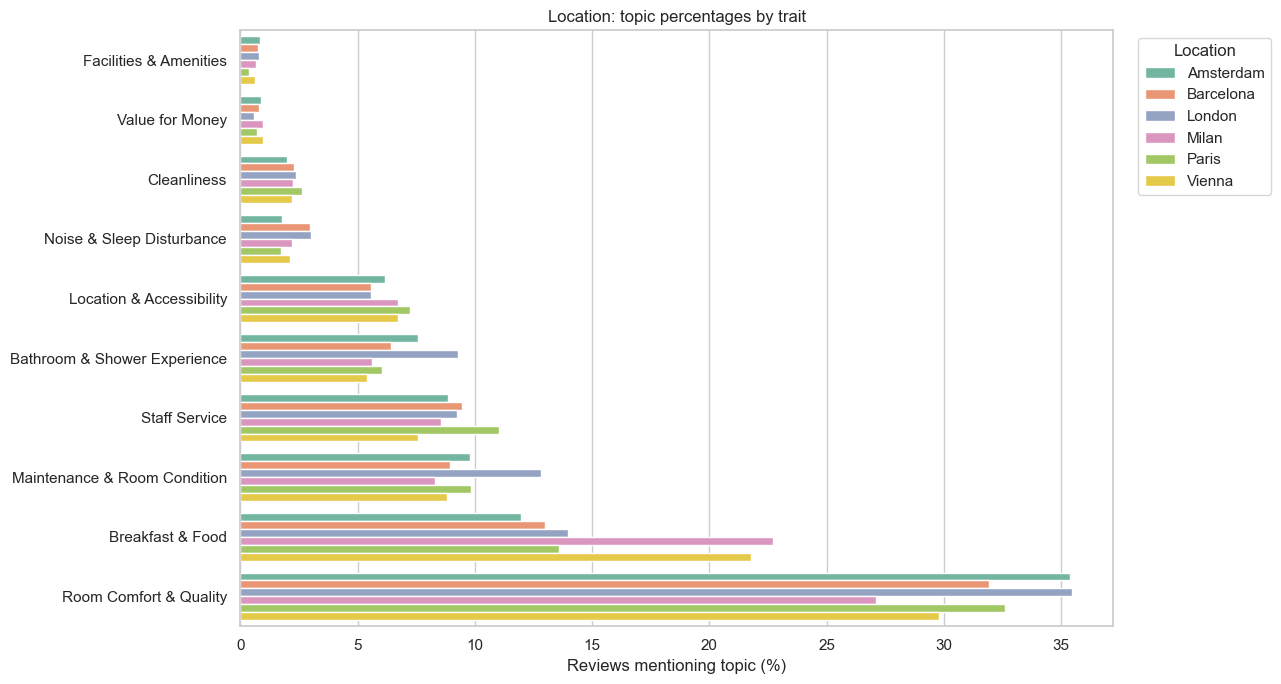

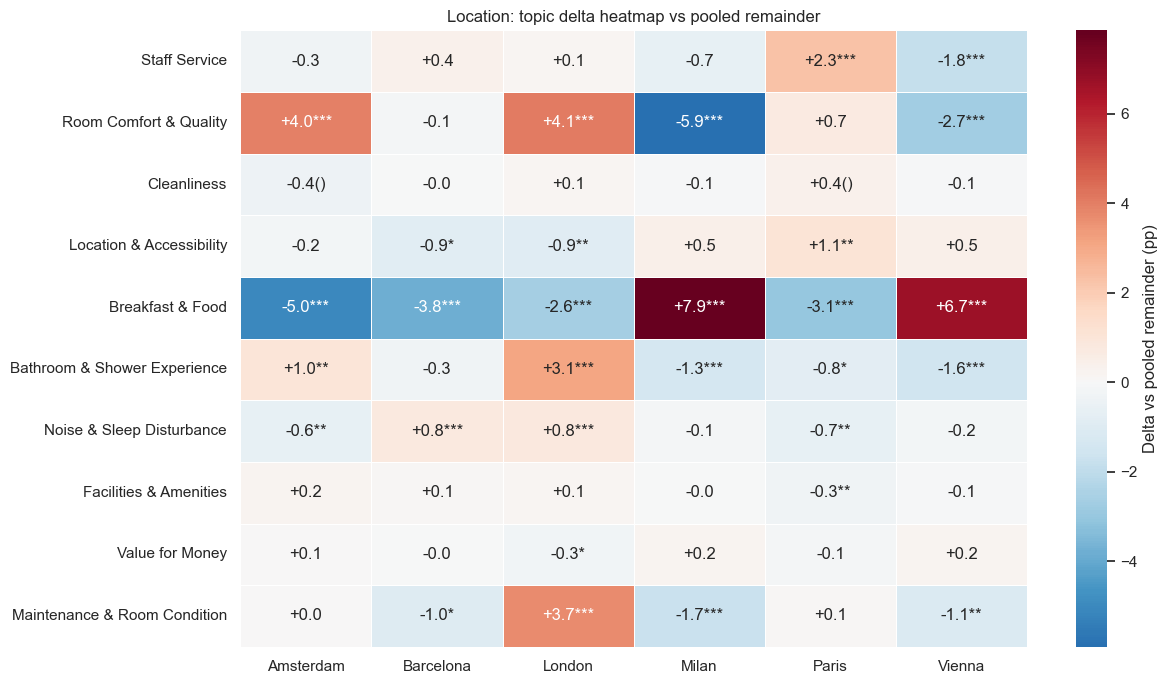

### Location Comparison
The chi-square goodness-of-fit tests show that topic mentions are not equally distributed within every location category (chi-square range 5059.02 to 6428.08; all p < 0.001), so some topics are consistently more prominent than others.
Wilcoxon signed-rank tests comparing each trait with the pooled remainder do not show a characteristic-wide shift in topic rank order at p < 0.05.
The figures below are used in the comparison analysis: a grouped bar chart of raw topic percentages and a delta heatmap showing over- and under-indexing against the pooled remainder.

- **Amsterdam.** Amsterdam is most strongly associated with Room Comfort & Quality (35.4%), Breakfast & Food (12.0%), and Maintenance & Room Condition (9.8%). Relative to the pooled remainder, it over-indexes on Room Comfort & Quality (+4.0 pp; p < 0.001) and Bathroom & Shower Experience (+1.0 pp; p = 0.005) and under-indexes on Breakfast & Food (-5.0 pp; p < 0.001) and Noise & Sleep Disturbance (-0.6 pp; p = 0.005).
- **Barcelona.** Barcelona is most strongly associated with Room Comfort & Quality (31.9%), Breakfast & Food (13.0%), and Staff Service (9.4%). Relative to the pooled remainder, it over-indexes on Noise & Sleep Disturbance (+0.8 pp; p < 0.001) and under-indexes on Breakfast & Food (-3.8 pp; p < 0.001), Maintenance & Room Condition (-1.0 pp; p = 0.022), and Location & Accessibility (-0.9 pp; p = 0.011).
- **London.** London is most strongly associated with Room Comfort & Quality (35.5%), Breakfast & Food (14.0%), and Maintenance & Room Condition (12.8%). Relative to the pooled remainder, it over-indexes on Room Comfort & Quality (+4.1 pp; p < 0.001), Maintenance & Room Condition (+3.7 pp; p < 0.001), and Bathroom & Shower Experience (+3.1 pp; p < 0.001) and under-indexes on Breakfast & Food (-2.6 pp; p < 0.001), Location & Accessibility (-0.9 pp; p = 0.008), and Value for Money (-0.3 pp; p = 0.033).
- **Milan.** Milan is most strongly associated with Room Comfort & Quality (27.1%), Breakfast & Food (22.7%), and Staff Service (8.6%). Relative to the pooled remainder, it over-indexes on Breakfast & Food (+7.9 pp; p < 0.001) and under-indexes on Room Comfort & Quality (-5.9 pp; p < 0.001), Maintenance & Room Condition (-1.7 pp; p < 0.001), and Bathroom & Shower Experience (-1.3 pp; p < 0.001).
- **Paris.** Paris is most strongly associated with Room Comfort & Quality (32.6%), Breakfast & Food (13.6%), and Staff Service (11.0%). Relative to the pooled remainder, it over-indexes on Staff Service (+2.3 pp; p < 0.001) and Location & Accessibility (+1.1 pp; p = 0.002) and under-indexes on Breakfast & Food (-3.1 pp; p < 0.001), Bathroom & Shower Experience (-0.8 pp; p = 0.020), and Noise & Sleep Disturbance (-0.7 pp; p = 0.001).
- **Vienna.** Vienna is most strongly associated with Room Comfort & Quality (29.8%), Breakfast & Food (21.8%), and Maintenance & Room Condition (8.8%). Relative to the pooled remainder, it over-indexes on Breakfast & Food (+6.7 pp; p < 0.001) and under-indexes on Room Comfort & Quality (-2.7 pp; p < 0.001), Staff Service (-1.8 pp; p < 0.001), and Bathroom & Shower Experience (-1.6 pp; p < 0.001).

,Trait,Top_Topics,Significantly_Higher,Significantly_Lower,Topic_Percentage_Figure,Delta_Heatmap_Figure
0,Amsterdam,"Room Comfort & Quality (35.4%), Breakfast & Fo...",Room Comfort & Quality (+4.0 pp; p < 0.001) an...,Breakfast & Food (-5.0 pp; p < 0.001) and Nois...,location_topic_percentages.png,location_topic_delta_heatmap.png
1,Barcelona,"Room Comfort & Quality (31.9%), Breakfast & Fo...",Noise & Sleep Disturbance (+0.8 pp; p < 0.001),"Breakfast & Food (-3.8 pp; p < 0.001), Mainten...",location_topic_percentages.png,location_topic_delta_heatmap.png
2,London,"Room Comfort & Quality (35.5%), Breakfast & Fo...","Room Comfort & Quality (+4.1 pp; p < 0.001), M...","Breakfast & Food (-2.6 pp; p < 0.001), Locatio...",location_topic_percentages.png,location_topic_delta_heatmap.png
3,Milan,"Room Comfort & Quality (27.1%), Breakfast & Fo...",Breakfast & Food (+7.9 pp; p < 0.001),"Room Comfort & Quality (-5.9 pp; p < 0.001), M...",location_topic_percentages.png,location_topic_delta_heatmap.png
4,Paris,"Room Comfort & Quality (32.6%), Breakfast & Fo...",Staff Service (+2.3 pp; p < 0.001) and Locatio...,"Breakfast & Food (-3.1 pp; p < 0.001), Bathroo...",location_topic_percentages.png,location_topic_delta_heatmap.png
5,Vienna,"Room Comfort & Quality (29.8%), Breakfast & Fo...",Breakfast & Food (+6.7 pp; p < 0.001),"Room Comfort & Quality (-2.7 pp; p < 0.001), S...",location_topic_percentages.png,location_topic_delta_heatmap.png


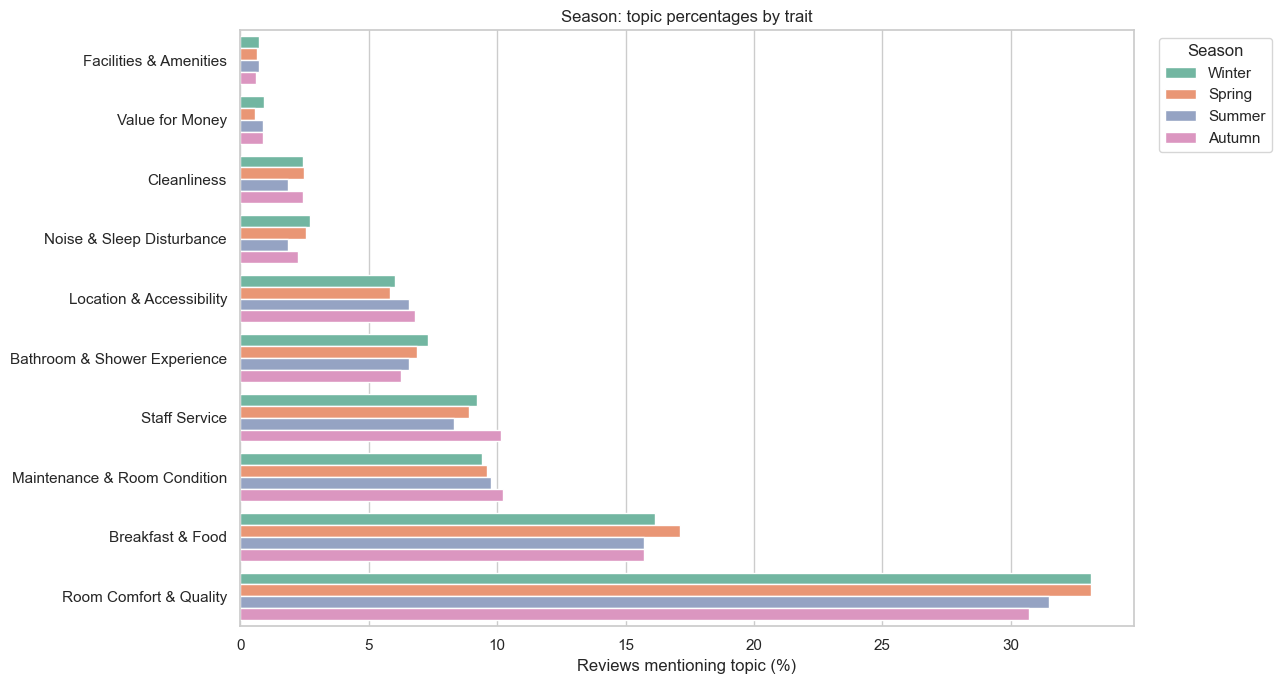

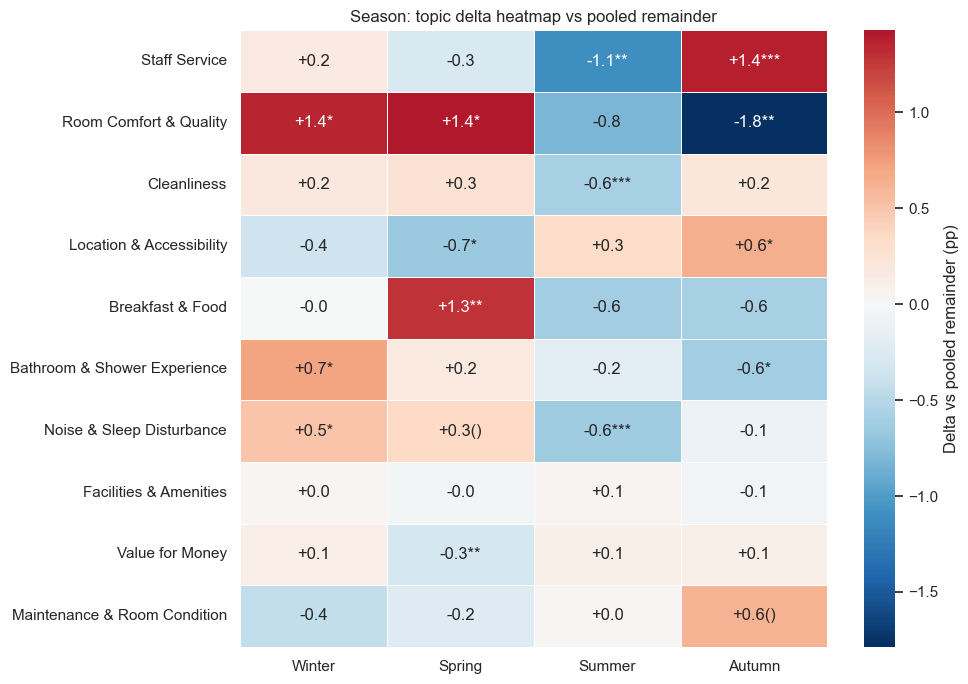

### Season Comparison
The chi-square goodness-of-fit tests show that topic mentions are not equally distributed within every season category (chi-square range 7322.42 to 9486.65; all p < 0.001), so some topics are consistently more prominent than others.
Wilcoxon signed-rank tests comparing each trait with the pooled remainder do not show a characteristic-wide shift in topic rank order at p < 0.05.
The figures below are used in the comparison analysis: a grouped bar chart of raw topic percentages and a delta heatmap showing over- and under-indexing against the pooled remainder.

- **Winter.** Winter is most strongly associated with Room Comfort & Quality (33.1%), Breakfast & Food (16.1%), and Maintenance & Room Condition (9.4%). Relative to the pooled remainder, it over-indexes on Room Comfort & Quality (+1.4 pp; p = 0.027), Bathroom & Shower Experience (+0.7 pp; p = 0.027), and Noise & Sleep Disturbance (+0.5 pp; p = 0.011).
- **Spring.** Spring is most strongly associated with Room Comfort & Quality (33.1%), Breakfast & Food (17.1%), and Maintenance & Room Condition (9.6%). Relative to the pooled remainder, it over-indexes on Room Comfort & Quality (+1.4 pp; p = 0.014) and Breakfast & Food (+1.3 pp; p = 0.005) and under-indexes on Location & Accessibility (-0.7 pp; p = 0.028) and Value for Money (-0.3 pp; p = 0.005).
- **Summer.** Summer is most strongly associated with Room Comfort & Quality (31.5%), Breakfast & Food (15.7%), and Maintenance & Room Condition (9.8%). Relative to the pooled remainder, it under-indexes on Staff Service (-1.1 pp; p = 0.001), Noise & Sleep Disturbance (-0.6 pp; p < 0.001), and Cleanliness (-0.6 pp; p < 0.001).
- **Autumn.** Autumn is most strongly associated with Room Comfort & Quality (30.7%), Breakfast & Food (15.7%), and Maintenance & Room Condition (10.2%). Relative to the pooled remainder, it over-indexes on Staff Service (+1.4 pp; p < 0.001) and Location & Accessibility (+0.6 pp; p = 0.036) and under-indexes on Room Comfort & Quality (-1.8 pp; p = 0.002) and Bathroom & Shower Experience (-0.6 pp; p = 0.047).

,Trait,Top_Topics,Significantly_Higher,Significantly_Lower,Topic_Percentage_Figure,Delta_Heatmap_Figure
0,Winter,"Room Comfort & Quality (33.1%), Breakfast & Fo...","Room Comfort & Quality (+1.4 pp; p = 0.027), B...",,season_topic_percentages.png,season_topic_delta_heatmap.png
1,Spring,"Room Comfort & Quality (33.1%), Breakfast & Fo...",Room Comfort & Quality (+1.4 pp; p = 0.014) an...,Location & Accessibility (-0.7 pp; p = 0.028) ...,season_topic_percentages.png,season_topic_delta_heatmap.png
2,Summer,"Room Comfort & Quality (31.5%), Breakfast & Fo...",,"Staff Service (-1.1 pp; p = 0.001), Noise & Sl...",season_topic_percentages.png,season_topic_delta_heatmap.png
3,Autumn,"Room Comfort & Quality (30.7%), Breakfast & Fo...",Staff Service (+1.4 pp; p < 0.001) and Locatio...,Room Comfort & Quality (-1.8 pp; p = 0.002) an...,season_topic_percentages.png,season_topic_delta_heatmap.png


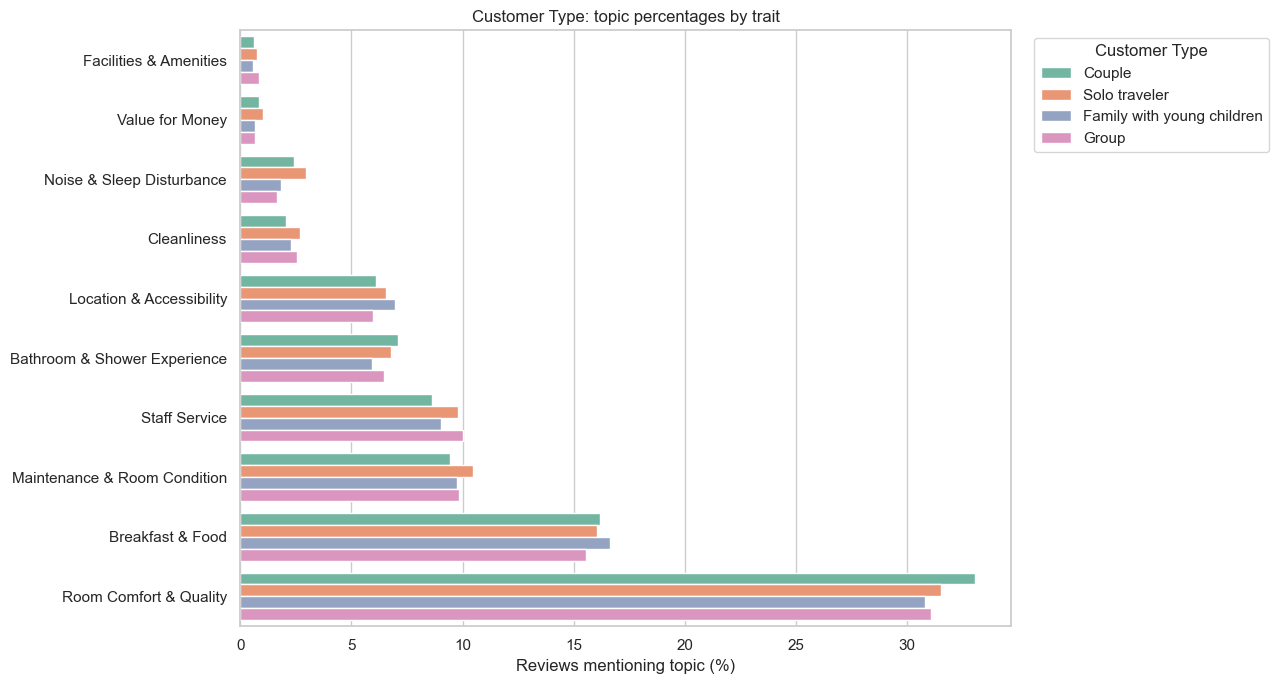

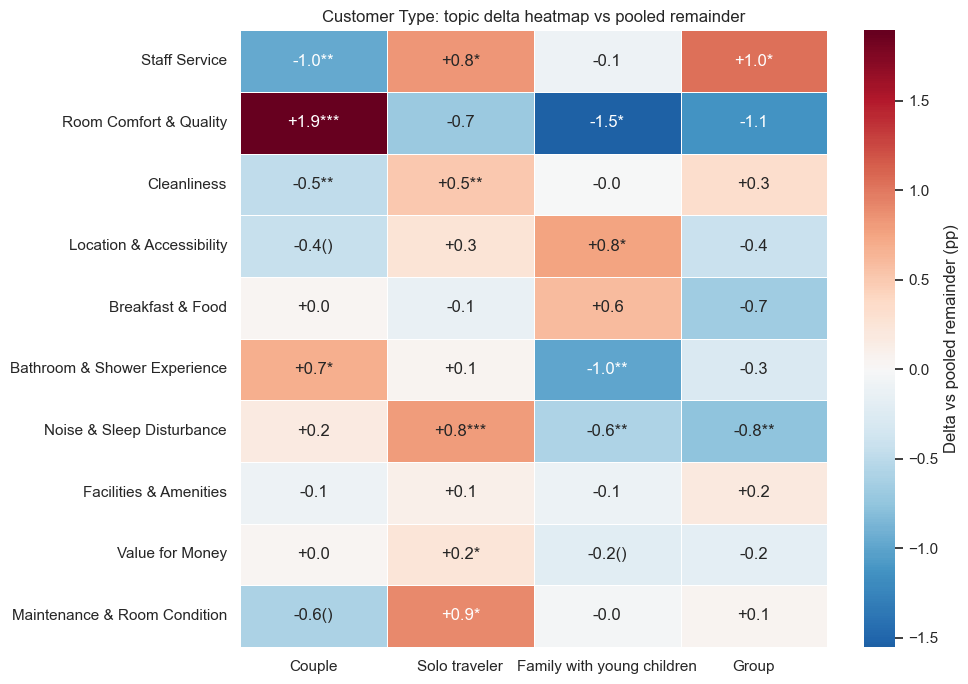

### Customer Type Comparison
The chi-square goodness-of-fit tests show that topic mentions are not equally distributed within every customer type category (chi-square range 4035.33 to 16652.12; all p < 0.001), so some topics are consistently more prominent than others.
Wilcoxon signed-rank tests comparing each trait with the pooled remainder do not show a characteristic-wide shift in topic rank order at p < 0.05. The closest result is Solo traveler (p = 0.084).
The figures below are used in the comparison analysis: a grouped bar chart of raw topic percentages and a delta heatmap showing over- and under-indexing against the pooled remainder.

- **Couple.** Couple is most strongly associated with Room Comfort & Quality (33.0%), Breakfast & Food (16.2%), and Maintenance & Room Condition (9.4%). Relative to the pooled remainder, it over-indexes on Room Comfort & Quality (+1.9 pp; p < 0.001) and Bathroom & Shower Experience (+0.7 pp; p = 0.010) and under-indexes on Staff Service (-1.0 pp; p = 0.002) and Cleanliness (-0.5 pp; p = 0.003).
- **Solo traveler.** Solo traveler is most strongly associated with Room Comfort & Quality (31.5%), Breakfast & Food (16.0%), and Maintenance & Room Condition (10.5%). Relative to the pooled remainder, it over-indexes on Maintenance & Room Condition (+0.9 pp; p = 0.022), Staff Service (+0.8 pp; p = 0.027), and Noise & Sleep Disturbance (+0.8 pp; p < 0.001).
- **Family with young children.** Family with young children is most strongly associated with Room Comfort & Quality (30.8%), Breakfast & Food (16.6%), and Maintenance & Room Condition (9.7%). Relative to the pooled remainder, it over-indexes on Location & Accessibility (+0.8 pp; p = 0.027) and under-indexes on Room Comfort & Quality (-1.5 pp; p = 0.017), Bathroom & Shower Experience (-1.0 pp; p = 0.004), and Noise & Sleep Disturbance (-0.6 pp; p = 0.005).
- **Group.** Group is most strongly associated with Room Comfort & Quality (31.1%), Breakfast & Food (15.6%), and Staff Service (10.0%). Relative to the pooled remainder, it over-indexes on Staff Service (+1.0 pp; p = 0.025) and under-indexes on Noise & Sleep Disturbance (-0.8 pp; p = 0.002).

,Trait,Top_Topics,Significantly_Higher,Significantly_Lower,Topic_Percentage_Figure,Delta_Heatmap_Figure
0,Couple,"Room Comfort & Quality (33.0%), Breakfast & Fo...",Room Comfort & Quality (+1.9 pp; p < 0.001) an...,Staff Service (-1.0 pp; p = 0.002) and Cleanli...,customer_type_topic_percentages.png,customer_type_topic_delta_heatmap.png
1,Solo traveler,"Room Comfort & Quality (31.5%), Breakfast & Fo...",Maintenance & Room Condition (+0.9 pp; p = 0.0...,,customer_type_topic_percentages.png,customer_type_topic_delta_heatmap.png
2,Family with young children,"Room Comfort & Quality (30.8%), Breakfast & Fo...",Location & Accessibility (+0.8 pp; p = 0.027),"Room Comfort & Quality (-1.5 pp; p = 0.017), B...",customer_type_topic_percentages.png,customer_type_topic_delta_heatmap.png
3,Group,"Room Comfort & Quality (31.1%), Breakfast & Fo...",Staff Service (+1.0 pp; p = 0.025),Noise & Sleep Disturbance (-0.8 pp; p = 0.002),customer_type_topic_percentages.png,customer_type_topic_delta_heatmap.png


Saved comparison summary table to: BERTModelRawOutputs\stats_tests_outputs\comparison_summary_table.csv
Saved comparison write-ups to: BERTModelRawOutputs\stats_tests_outputs\comparison_writeups.md
Saved comparison figures to: BERTModelRawOutputs\stats_tests_outputs\comparison_figures


In [21]:
comparison_figure_dir = output_dir / "comparison_figures"
comparison_figure_dir.mkdir(exist_ok=True)

comparison_summary_frames = []
comparison_markdown_blocks = []

for characteristic, spec in CHARACTERISTIC_SPECS.items():
    result = characteristic_results[characteristic]
    percentage_figure = plot_topic_percentage_bars(
        result["percentages"],
        characteristic,
        comparison_figure_dir,
    )
    delta_figure = plot_delta_heatmap(
        result["ztests"],
        spec["traits"],
        characteristic,
        comparison_figure_dir,
    )

    comparison_summary = build_comparison_summary_table(characteristic, result)
    comparison_summary["Topic_Percentage_Figure"] = percentage_figure.name
    comparison_summary["Delta_Heatmap_Figure"] = delta_figure.name
    comparison_summary_frames.append(comparison_summary)

    comparison_text = build_characteristic_comparison(characteristic, result)
    comparison_markdown_blocks.append(comparison_text)

    display(Markdown(comparison_text))
    display(
        comparison_summary[
            [
                "Trait",
                "Top_Topics",
                "Significantly_Higher",
                "Significantly_Lower",
                "Topic_Percentage_Figure",
                "Delta_Heatmap_Figure",
            ]
        ]
    )

comparison_summary_table = pd.concat(comparison_summary_frames, ignore_index=True)
comparison_summary_path = output_dir / "comparison_summary_table.csv"
comparison_markdown_path = output_dir / "comparison_writeups.md"
comparison_summary_table.to_csv(comparison_summary_path, index=False)
comparison_markdown_path.write_text("\n\n".join(comparison_markdown_blocks), encoding="utf-8")

print(f"Saved comparison summary table to: {comparison_summary_path}")
print(f"Saved comparison write-ups to: {comparison_markdown_path}")
print(f"Saved comparison figures to: {comparison_figure_dir}")

## Topic Sentiment Statistical Tests <a id="topic-sentiment-statistical-tests"></a>

This section adds fragment-level ROBERTa topic sentiment tests. It fits mixed-effects models with hotel random intercepts for each topic, applies FDR correction across topics, and saves sentiment-specific outputs under `stats_tests_outputs/sentiment_tests`.

In [22]:
from __future__ import annotations

import ast
import warnings
from itertools import combinations
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.stats import chi2, f_oneway, kruskal, norm

try:
    import statsmodels.formula.api as smf
    from statsmodels.stats.multitest import multipletests
except ImportError as exc:  # pragma: no cover - dependency guard
    raise SystemExit(
        "This script requires statsmodels. Install the requirements first."
    ) from exc

ZERO_SHOT_MAJOR_TOPICS = [
    "Staff Service",
    "Room Comfort & Quality",
    "Cleanliness",
    "Location & Accessibility",
    "Breakfast & Food",
    "Bathroom & Shower Experience",
    "Noise & Sleep Disturbance",
    "Facilities & Amenities",
    "Value for Money",
    "Maintenance & Room Condition",
]

CITY_ORDER = ["Amsterdam", "Barcelona", "London", "Milan", "Paris", "Vienna"]
SEASON_ORDER = ["Winter", "Spring", "Summer", "Autumn"]
TRAVELER_TYPE_ORDER = [
    "Couple",
    "Solo traveler",
    "Family with young children",
    "Group",
]

CHARACTERISTIC_SPECS = {
    "Location": {"column": "City", "traits": CITY_ORDER},
    "Season": {"column": "Season", "traits": SEASON_ORDER},
    "Customer Type": {"column": "TravelerType", "traits": TRAVELER_TYPE_ORDER},
}

MIN_FRAGMENTS_PER_TRAIT = 3
MIN_HOTELS_PER_TRAIT = 2
MIN_FRAGMENTS_PER_HOTEL_TRAIT = 3
SENTIMENT_MIN = -1.0
SENTIMENT_MAX = 1.0


def extract_city(address: str) -> str | pd.NA:
    if not isinstance(address, str):
        return pd.NA
    address_lower = address.lower()
    for city in CITY_ORDER:
        if city.lower() in address_lower:
            return city
    if "netherlands" in address_lower:
        return "Amsterdam"
    if "spain" in address_lower:
        return "Barcelona"
    if "united kingdom" in address_lower:
        return "London"
    if "italy" in address_lower:
        return "Milan"
    if "france" in address_lower:
        return "Paris"
    if "austria" in address_lower:
        return "Vienna"
    return pd.NA


def assign_season(month: float | int | None) -> str | pd.NA:
    if pd.isna(month):
        return pd.NA
    month = int(month)
    if month in (12, 1, 2):
        return "Winter"
    if month in (3, 4, 5):
        return "Spring"
    if month in (6, 7, 8):
        return "Summer"
    return "Autumn"


def extract_traveler_type(tags_str: str) -> str | pd.NA:
    if not isinstance(tags_str, str) or not tags_str.strip():
        return pd.NA
    try:
        tags_list = ast.literal_eval(tags_str)
    except (SyntaxError, ValueError):
        return pd.NA
    tags_lower = [str(tag).strip().lower() for tag in tags_list]
    if any("couple" in tag for tag in tags_lower):
        return "Couple"
    if any("solo" in tag or "single" in tag for tag in tags_lower):
        return "Solo traveler"
    if any("family" in tag or "child" in tag or "kid" in tag for tag in tags_lower):
        return "Family with young children"
    if any("group" in tag or "friend" in tag for tag in tags_lower):
        return "Group"
    return pd.NA


def significance_symbol(p_value: float | None) -> str:
    if pd.isna(p_value):
        return ""
    if p_value <= 0.001:
        return "***"
    if p_value <= 0.01:
        return "**"
    if p_value <= 0.05:
        return "*"
    if p_value <= 0.10:
        return "()"
    return ""


def format_p_value_text(p_value: float | None) -> str:
    if pd.isna(p_value):
        return "p = NA"
    if p_value < 0.001:
        return "p < 0.001"
    return f"p = {p_value:.3f}"


def join_phrases(items: list[str]) -> str:
    items = [item for item in items if item]
    if not items:
        return ""
    if len(items) == 1:
        return items[0]
    if len(items) == 2:
        return f"{items[0]} and {items[1]}"
    return f"{', '.join(items[:-1])}, and {items[-1]}"


def safe_slug(text: str) -> str:
    slug = "".join(char.lower() if char.isalnum() else "_" for char in str(text))
    while "__" in slug:
        slug = slug.replace("__", "_")
    return slug.strip("_")


def locate_existing_path(candidates: list[Path], description: str) -> Path:
    path = next((path for path in candidates if path.exists()), None)
    if path is None:
        raise FileNotFoundError(f"Could not find {description}. Checked: {candidates}")
    return path


def load_sentiment_ready_documents() -> tuple[pd.DataFrame, Path]:
    doc_info_path = locate_existing_path(
        [
            Path("BERTModelRawOutputs") / "Hotel_Document_Info.csv",
            Path("code") / "BERTModelRawOutputs" / "Hotel_Document_Info.csv",
        ],
        "Hotel_Document_Info.csv",
    )
    sentiment_path = locate_existing_path(
        [
            Path("BERTModelRawOutputs") / "Hotel_Sentiment_Scores.csv",
            Path("code") / "BERTModelRawOutputs" / "Hotel_Sentiment_Scores.csv",
        ],
        "Hotel_Sentiment_Scores.csv",
    )
    review_data_path = locate_existing_path(
        [
            Path("Datasets") / "Hotel_Reviews_StratSamp_Balanced.csv",
            Path("..") / "Datasets" / "Hotel_Reviews_StratSamp_Balanced.csv",
        ],
        "Hotel_Reviews_StratSamp_Balanced.csv",
    )

    doc_inf = pd.read_csv(doc_info_path)
    sentiment_df = pd.read_csv(sentiment_path)
    review_inf = pd.read_csv(review_data_path)

    required_doc_columns = {"Person_id", "Hotel_Name", "Semantic_Label"}
    missing_doc_columns = required_doc_columns.difference(doc_inf.columns)
    if missing_doc_columns:
        raise KeyError(f"{doc_info_path} is missing columns: {sorted(missing_doc_columns)}")

    required_sentiment_columns = {"Sentiment_Label", "Sentiment_Score"}
    missing_sentiment_columns = required_sentiment_columns.difference(sentiment_df.columns)
    if missing_sentiment_columns:
        raise KeyError(
            f"{sentiment_path} is missing columns: {sorted(missing_sentiment_columns)}"
        )

    if len(doc_inf) != len(sentiment_df):
        raise ValueError(
            f"{doc_info_path} has {len(doc_inf):,} rows but {sentiment_path} has "
            f"{len(sentiment_df):,}. They need to align row-for-row."
        )

    required_review_columns = {"ID", "Hotel_Name", "Review_Date", "Tags"}
    missing_review_columns = required_review_columns.difference(review_inf.columns)
    if missing_review_columns:
        raise KeyError(
            f"{review_data_path} is missing columns: {sorted(missing_review_columns)}"
        )

    doc_inf = pd.concat(
        [
            doc_inf.reset_index(drop=True),
            sentiment_df[["Sentiment_Label", "Sentiment_Score"]].reset_index(drop=True),
        ],
        axis=1,
    )

    if "City" not in review_inf.columns:
        if "Hotel_Address" not in review_inf.columns:
            raise KeyError(
                f"{review_data_path} needs either 'City' or 'Hotel_Address' to derive location."
            )
        review_inf["City"] = review_inf["Hotel_Address"].apply(extract_city)

    review_inf["Review_Date"] = pd.to_datetime(
        review_inf["Review_Date"], dayfirst=False, errors="coerce"
    )
    review_inf["Season"] = review_inf["Review_Date"].dt.month.apply(assign_season)
    review_inf["TravelerType"] = review_inf["Tags"].apply(extract_traveler_type)

    review_lookup = (
        review_inf[["ID", "City", "Review_Date", "Season", "TravelerType"]]
        .rename(columns={"ID": "Person_id"})
        .drop_duplicates(subset=["Person_id"])
    )

    doc_inf["Person_id"] = pd.to_numeric(doc_inf["Person_id"], errors="coerce").astype("Int64")
    review_lookup["Person_id"] = pd.to_numeric(review_lookup["Person_id"], errors="coerce").astype(
        "Int64"
    )

    doc_inf = doc_inf.merge(review_lookup, on="Person_id", how="left")

    hotel_city_lookup = review_inf[["Hotel_Name", "City"]].dropna().drop_duplicates()
    if hotel_city_lookup["Hotel_Name"].duplicated().any():
        raise ValueError(
            f"{review_data_path} maps at least one hotel to multiple cities; "
            "cannot build a clean location lookup."
        )

    doc_inf = doc_inf.merge(
        hotel_city_lookup.rename(columns={"City": "City_from_hotel"}),
        on="Hotel_Name",
        how="left",
    )
    doc_inf["City"] = doc_inf["City"].fillna(doc_inf["City_from_hotel"])
    doc_inf = doc_inf.drop(columns=["City_from_hotel"])

    doc_inf["Sentiment_Score"] = pd.to_numeric(doc_inf["Sentiment_Score"], errors="coerce").clip(SENTIMENT_MIN, SENTIMENT_MAX)
    doc_inf = doc_inf.dropna(
        subset=["Person_id", "Hotel_Name", "Semantic_Label", "Sentiment_Score"]
    ).copy()

    if "Topic" in doc_inf.columns:
        topic_numeric = pd.to_numeric(doc_inf["Topic"], errors="coerce")
        doc_inf = doc_inf[topic_numeric != -1].copy()

    doc_inf = doc_inf[doc_inf["Semantic_Label"].isin(ZERO_SHOT_MAJOR_TOPICS)].copy()

    output_dir = doc_info_path.parent / "stats_tests_outputs" / "sentiment_tests"
    return doc_inf, output_dir


def build_fragment_support(data: pd.DataFrame, trait_col: str, trait_order: list[str]) -> pd.DataFrame:
    summary = (
        data.dropna(subset=[trait_col])
        .groupby(["Semantic_Label", trait_col], observed=False)
        .agg(
            Fragment_Count=("Sentiment_Score", "size"),
            Review_Count=("Person_id", "nunique"),
            Hotel_Count=("Hotel_Name", "nunique"),
            Mean_Sentiment=("Sentiment_Score", "mean"),
            Std_Sentiment=("Sentiment_Score", "std"),
        )
        .reset_index()
        .rename(columns={trait_col: "Trait"})
    )
    summary["Trait_Order"] = summary["Trait"].map({trait: idx for idx, trait in enumerate(trait_order)})
    return summary.sort_values(["Semantic_Label", "Trait_Order"]).reset_index(drop=True)


def build_hotel_trait_means(
    data: pd.DataFrame, trait_col: str, trait_order: list[str]
) -> pd.DataFrame:
    hotel_means = (
        data.dropna(subset=[trait_col])
        .groupby(["Hotel_Name", "Semantic_Label", trait_col], observed=False)
        .agg(
            Mean_Sentiment=("Sentiment_Score", "mean"),
            Fragment_Count=("Sentiment_Score", "size"),
            Review_Count=("Person_id", "nunique"),
        )
        .reset_index()
        .rename(columns={trait_col: "Trait"})
    )
    hotel_means = hotel_means[hotel_means["Fragment_Count"] >= MIN_FRAGMENTS_PER_HOTEL_TRAIT].copy()
    hotel_means["Trait_Order"] = hotel_means["Trait"].map(
        {trait: idx for idx, trait in enumerate(trait_order)}
    )
    return hotel_means.sort_values(
        ["Semantic_Label", "Trait_Order", "Hotel_Name"]
    ).reset_index(drop=True)


def fit_mixedlm(formula: str, data: pd.DataFrame, group_col: str):
    last_exc = None
    for method in ("lbfgs", "powell", "nm"):
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                model = smf.mixedlm(formula, data=data, groups=data[group_col], re_formula="1")
                result = model.fit(reml=False, method=method, disp=False)
            note = ""
            if not getattr(result, "converged", True):
                note = f"MixedLM fit with {method} but did not report convergence."
            return result, method, note
        except Exception as exc:  # pragma: no cover - fit failures depend on local data
            last_exc = exc
    raise last_exc


def fixed_effect_covariance(result) -> pd.DataFrame:
    fe_names = list(result.fe_params.index)
    cov = result.cov_params()
    if not isinstance(cov, pd.DataFrame):
        cov = pd.DataFrame(cov, index=result.params.index, columns=result.params.index)
    return cov.loc[fe_names, fe_names]


def clip_sentiment_score(value: float | None) -> float:
    if pd.isna(value):
        return np.nan
    return float(np.clip(value, SENTIMENT_MIN, SENTIMENT_MAX))


def compute_wald_omnibus(result, trait_col: str) -> tuple[float, int, str]:
    fe_names = list(result.fe_params.index)
    trait_coef_names = [
        name for name in fe_names if name.startswith(f"C({trait_col})[T.")
    ]
    if not trait_coef_names:
        return np.nan, 0, "No non-reference trait coefficients available for omnibus testing."
    fe_cov = fixed_effect_covariance(result)
    beta = result.fe_params.loc[trait_coef_names].to_numpy(dtype=float)
    cov = fe_cov.loc[trait_coef_names, trait_coef_names].to_numpy(dtype=float)
    if not np.isfinite(beta).all() or not np.isfinite(cov).all():
        return np.nan, len(trait_coef_names), "Non-finite fixed-effect estimates or covariance."
    try:
        statistic = float(beta.T @ np.linalg.pinv(cov) @ beta)
    except Exception as exc:
        return np.nan, len(trait_coef_names), str(exc)
    if not np.isfinite(statistic):
        return np.nan, len(trait_coef_names), "Non-finite Wald statistic."
    return max(statistic, 0.0), len(trait_coef_names), ""


def trait_design_vector(fe_names: list[str], trait_col: str, trait: str) -> pd.Series:
    vector = pd.Series(0.0, index=fe_names, dtype=float)
    if "Intercept" in vector.index:
        vector["Intercept"] = 1.0
    coef_name = f"C({trait_col})[T.{trait}]"
    if coef_name in vector.index:
        vector[coef_name] = 1.0
    return vector


def apply_fdr_adjustment(
    df: pd.DataFrame,
    p_col: str = "P_Value",
    alpha: float = 0.05,
    adjusted_col: str = "Adjusted_P_Value",
) -> pd.DataFrame:
    df = df.copy()
    df[adjusted_col] = np.nan
    df["Adjusted_Significant"] = False
    df["Adjusted_Significance"] = ""

    valid = df[p_col].notna()
    if valid.any():
        rejected, adjusted, _, _ = multipletests(
            df.loc[valid, p_col], alpha=alpha, method="fdr_bh"
        )
        df.loc[valid, adjusted_col] = adjusted
        df.loc[valid, "Adjusted_Significant"] = rejected
        df.loc[valid, "Adjusted_Significance"] = [
            significance_symbol(value) for value in adjusted
        ]
    return df


def prepare_topic_support(
    topic_df: pd.DataFrame, trait_col: str, trait_order: list[str]
) -> pd.DataFrame:
    support = (
        topic_df.dropna(subset=[trait_col])
        .groupby(trait_col, observed=False)
        .agg(
            Fragment_Count=("Sentiment_Score", "size"),
            Review_Count=("Person_id", "nunique"),
            Hotel_Count=("Hotel_Name", "nunique"),
            Observed_Mean=("Sentiment_Score", "mean"),
            Observed_Std=("Sentiment_Score", "std"),
        )
        .reindex(trait_order)
        .reset_index()
        .rename(columns={trait_col: "Trait"})
    )
    support = support[support["Fragment_Count"].notna()].copy()
    if support.empty:
        return support
    for column in ("Fragment_Count", "Review_Count", "Hotel_Count"):
        support[column] = support[column].astype(int)
    support["Trait_Order"] = support["Trait"].map({trait: idx for idx, trait in enumerate(trait_order)})
    return support.sort_values("Trait_Order").reset_index(drop=True)


def run_mixed_effects_for_characteristic(
    data: pd.DataFrame,
    characteristic: str,
    trait_col: str,
    trait_order: list[str],
    alpha: float,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    omnibus_rows = []
    mean_rows = []
    pairwise_rows = []

    for topic in ZERO_SHOT_MAJOR_TOPICS:
        topic_df = data[data["Semantic_Label"] == topic].copy()
        support = prepare_topic_support(topic_df, trait_col, trait_order)
        available_traits = support["Trait"].tolist() if not support.empty else []
        eligible_traits = [
            trait
            for trait in available_traits
            if int(support.loc[support["Trait"] == trait, "Fragment_Count"].iloc[0])
            >= MIN_FRAGMENTS_PER_TRAIT
            and int(support.loc[support["Trait"] == trait, "Hotel_Count"].iloc[0])
            >= MIN_HOTELS_PER_TRAIT
        ]
        excluded_traits = [trait for trait in available_traits if trait not in eligible_traits]
        note_parts = []
        if excluded_traits:
            note_parts.append("Excluded sparse traits: " + ", ".join(excluded_traits))

        analysis_df = topic_df[topic_df[trait_col].isin(eligible_traits)].copy()
        if analysis_df["Hotel_Name"].nunique() < 2:
            note_parts.append("Need at least two hotels overall for the random intercept model.")

        if len(eligible_traits) < 2 or analysis_df["Hotel_Name"].nunique() < 2:
            omnibus_rows.append(
                {
                    "Characteristic": characteristic,
                    "Topic": topic,
                    "Trait_Column": trait_col,
                    "Omnibus_Test": "Wald chi-square",
                    "Reference_Trait": eligible_traits[0] if eligible_traits else pd.NA,
                    "Traits_Tested": ", ".join(eligible_traits),
                    "Fragments_Used": int(len(analysis_df)),
                    "Reviews_Used": int(analysis_df["Person_id"].nunique()),
                    "Hotels_Used": int(analysis_df["Hotel_Name"].nunique()),
                    "Omnibus_Statistic": np.nan,
                    "Degrees_of_Freedom": np.nan,
                    "P_Value": np.nan,
                    "Significance": "",
                    "Model_Status": "skipped",
                    "Fit_Method": "",
                    "Note": " ".join(note_parts)
                    or (
                        f"Need at least two trait levels with >= {MIN_FRAGMENTS_PER_TRAIT} fragments "
                        f"and >= {MIN_HOTELS_PER_TRAIT} hotels."
                    ),
                }
            )
            continue

        analysis_df[trait_col] = pd.Categorical(
            analysis_df[trait_col], categories=eligible_traits, ordered=True
        )

        try:
            full_result, fit_method, fit_note = fit_mixedlm(
                f"Sentiment_Score ~ C({trait_col})", analysis_df, "Hotel_Name"
            )
            omnibus_stat, df_diff, omnibus_note = compute_wald_omnibus(full_result, trait_col)
        except Exception as exc:  # pragma: no cover - fit failures depend on local data
            omnibus_rows.append(
                {
                    "Characteristic": characteristic,
                    "Topic": topic,
                    "Trait_Column": trait_col,
                    "Omnibus_Test": "Wald chi-square",
                    "Reference_Trait": eligible_traits[0],
                    "Traits_Tested": ", ".join(eligible_traits),
                    "Fragments_Used": int(len(analysis_df)),
                    "Reviews_Used": int(analysis_df["Person_id"].nunique()),
                    "Hotels_Used": int(analysis_df["Hotel_Name"].nunique()),
                    "Omnibus_Statistic": np.nan,
                    "Degrees_of_Freedom": np.nan,
                    "P_Value": np.nan,
                    "Significance": "",
                    "Model_Status": "fit_failed",
                    "Fit_Method": "",
                    "Note": " ".join(note_parts + [str(exc)]),
                }
            )
            continue

        note_parts.extend(part for part in (fit_note, omnibus_note) if part)
        p_value = (
            chi2.sf(omnibus_stat, df_diff)
            if df_diff > 0 and np.isfinite(omnibus_stat)
            else np.nan
        )
        model_status = "ok" if np.isfinite(omnibus_stat) else "nonfinite_omnibus"

        omnibus_rows.append(
            {
                "Characteristic": characteristic,
                "Topic": topic,
                "Trait_Column": trait_col,
                "Omnibus_Test": "Wald chi-square",
                "Reference_Trait": eligible_traits[0],
                "Traits_Tested": ", ".join(eligible_traits),
                "Fragments_Used": int(len(analysis_df)),
                "Reviews_Used": int(analysis_df["Person_id"].nunique()),
                "Hotels_Used": int(analysis_df["Hotel_Name"].nunique()),
                "Omnibus_Statistic": omnibus_stat,
                "Degrees_of_Freedom": df_diff,
                "P_Value": p_value,
                "Significance": significance_symbol(p_value),
                "Model_Status": model_status,
                "Fit_Method": fit_method,
                "Note": " ".join(note_parts),
            }
        )

        fe_names = list(full_result.fe_params.index)
        fe_cov = fixed_effect_covariance(full_result)
        fe_values = full_result.fe_params.reindex(fe_names)
        if not np.isfinite(fe_values.to_numpy(dtype=float)).all() or not np.isfinite(
            fe_cov.to_numpy(dtype=float)
        ).all():
            omnibus_rows[-1]["Model_Status"] = "nonfinite_fixed_effects"
            omnibus_rows[-1]["Note"] = " ".join(
                note_parts
                + [
                    "Non-finite fixed-effect estimates or covariance; skipped marginal means and pairwise contrasts."
                ]
            ).strip()
            continue

        mean_lookup = {}
        for support_row in support[support["Trait"].isin(eligible_traits)].itertuples():
            design = trait_design_vector(fe_names, trait_col, support_row.Trait)
            estimate = float(np.dot(design.values, fe_values.values))
            variance = float(design.values @ fe_cov.values @ design.values)
            if not np.isfinite(variance):
                se = np.nan
            else:
                variance = max(variance, 0.0)
                se = np.sqrt(variance)
            ci_low_raw = estimate - 1.96 * se if np.isfinite(se) else np.nan
            ci_high_raw = estimate + 1.96 * se if np.isfinite(se) else np.nan
            mean_lookup[support_row.Trait] = estimate
            mean_rows.append(
                {
                    "Characteristic": characteristic,
                    "Topic": topic,
                    "Trait": support_row.Trait,
                    "Trait_Order": int(support_row.Trait_Order),
                    "Observed_Fragment_Count": int(support_row.Fragment_Count),
                    "Observed_Review_Count": int(support_row.Review_Count),
                    "Observed_Hotel_Count": int(support_row.Hotel_Count),
                    "Observed_Mean_Sentiment": float(support_row.Observed_Mean),
                    "Observed_Std_Sentiment": float(support_row.Observed_Std)
                    if pd.notna(support_row.Observed_Std)
                    else np.nan,
                    "Estimated_Mean_Raw": estimate,
                    "Estimated_Mean": clip_sentiment_score(estimate),
                    "Estimated_SE": se,
                    "CI_Low_Raw": ci_low_raw,
                    "CI_High_Raw": ci_high_raw,
                    "CI_Low": clip_sentiment_score(ci_low_raw),
                    "CI_High": clip_sentiment_score(ci_high_raw),
                    "Fit_Method": fit_method,
                }
            )

        topic_pairwise_rows = []
        for trait_a, trait_b in combinations(eligible_traits, 2):
            design_a = trait_design_vector(fe_names, trait_col, trait_a)
            design_b = trait_design_vector(fe_names, trait_col, trait_b)
            contrast = design_a - design_b
            mean_diff = float(np.dot(contrast.values, fe_values.values))
            variance = float(contrast.values @ fe_cov.values @ contrast.values)
            if not np.isfinite(variance):
                se = np.nan
            else:
                variance = max(variance, 0.0)
                se = np.sqrt(variance)
            if not np.isfinite(se):
                z_stat = np.nan
                pair_p = np.nan
            elif se == 0:
                z_stat = 0.0
                pair_p = 1.0
            else:
                z_stat = mean_diff / se
                pair_p = 2 * norm.sf(abs(z_stat))
            ci_low = mean_diff - 1.96 * se if np.isfinite(se) else np.nan
            ci_high = mean_diff + 1.96 * se if np.isfinite(se) else np.nan
            topic_pairwise_rows.append(
                {
                    "Characteristic": characteristic,
                    "Topic": topic,
                    "Trait_A": trait_a,
                    "Trait_B": trait_b,
                    "Trait_A_Mean": clip_sentiment_score(mean_lookup[trait_a]),
                    "Trait_B_Mean": clip_sentiment_score(mean_lookup[trait_b]),
                    "Mean_Diff": mean_diff,
                    "SE": se,
                    "Z_Statistic": z_stat,
                    "P_Value": pair_p,
                    "CI_Low": ci_low,
                    "CI_High": ci_high,
                    "Fit_Method": fit_method,
                }
            )

        if topic_pairwise_rows:
            pairwise_df = pd.DataFrame(topic_pairwise_rows)
            pairwise_df["Adjusted_P_Value"] = np.nan
            pairwise_df["Adjusted_Significant"] = False
            pairwise_df["Adjusted_Significance"] = ""
            valid_pairwise = pairwise_df["P_Value"].notna()
            if valid_pairwise.any():
                rejected, adjusted, _, _ = multipletests(
                    pairwise_df.loc[valid_pairwise, "P_Value"], alpha=alpha, method="holm"
                )
                pairwise_df.loc[valid_pairwise, "Adjusted_P_Value"] = adjusted
                pairwise_df.loc[valid_pairwise, "Adjusted_Significant"] = rejected
                pairwise_df.loc[valid_pairwise, "Adjusted_Significance"] = [
                    significance_symbol(value) for value in adjusted
                ]
            pairwise_df["Adjustment_Method"] = "holm"
            pairwise_rows.extend(pairwise_df.to_dict("records"))

    return (
        pd.DataFrame(omnibus_rows),
        pd.DataFrame(mean_rows),
        pd.DataFrame(pairwise_rows),
    )
def run_sensitivity_tests(
    hotel_trait_means: pd.DataFrame,
    characteristic: str,
    trait_order: list[str],
    alpha: float,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    anova_rows = []
    kruskal_rows = []

    for topic in ZERO_SHOT_MAJOR_TOPICS:
        topic_df = hotel_trait_means[hotel_trait_means["Semantic_Label"] == topic].copy()
        support = (
            topic_df.groupby("Trait", observed=False)
            .agg(
                Hotel_Count=("Hotel_Name", "nunique"),
                Mean_Hotel_Sentiment=("Mean_Sentiment", "mean"),
            )
            .reindex(trait_order)
            .reset_index()
        )
        support = support[support["Hotel_Count"].notna()].copy()
        if not support.empty:
            support["Hotel_Count"] = support["Hotel_Count"].astype(int)
        eligible_traits = [
            row.Trait for row in support.itertuples() if int(row.Hotel_Count) >= MIN_HOTELS_PER_TRAIT
        ]
        groups = [
            topic_df.loc[topic_df["Trait"] == trait, "Mean_Sentiment"].to_numpy()
            for trait in eligible_traits
        ]
        note = ""
        if len(eligible_traits) < 2:
            note = (
                f"Need at least two trait levels with >= {MIN_HOTELS_PER_TRAIT} hotel-level means."
            )

        anova_stat = np.nan
        anova_p = np.nan
        kruskal_stat = np.nan
        kruskal_p = np.nan
        if len(eligible_traits) >= 2 and all(len(group) >= MIN_HOTELS_PER_TRAIT for group in groups):
            try:
                anova_stat, anova_p = f_oneway(*groups)
            except Exception as exc:  # pragma: no cover - data dependent
                note = f"{note} {exc}".strip()
            try:
                kruskal_stat, kruskal_p = kruskal(*groups)
            except Exception as exc:  # pragma: no cover - data dependent
                note = f"{note} {exc}".strip()

        base_row = {
            "Characteristic": characteristic,
            "Topic": topic,
            "Traits_Tested": ", ".join(eligible_traits),
            "Hotel_Trait_Mean_Rows": int(len(topic_df)),
            "Hotels_Used": int(topic_df["Hotel_Name"].nunique()),
            "Note": note,
        }
        anova_rows.append(
            {
                **base_row,
                "Statistic": anova_stat,
                "Degrees_of_Freedom_Between": max(len(eligible_traits) - 1, 0),
                "Degrees_of_Freedom_Within": max(len(topic_df) - len(eligible_traits), 0),
                "P_Value": anova_p,
                "Significance": significance_symbol(anova_p),
            }
        )
        kruskal_rows.append(
            {
                **base_row,
                "Statistic": kruskal_stat,
                "Degrees_of_Freedom": max(len(eligible_traits) - 1, 0),
                "P_Value": kruskal_p,
                "Significance": significance_symbol(kruskal_p),
            }
        )

    anova_df = apply_fdr_adjustment(pd.DataFrame(anova_rows), alpha=alpha)
    kruskal_df = apply_fdr_adjustment(pd.DataFrame(kruskal_rows), alpha=alpha)
    return anova_df, kruskal_df


def build_sentiment_writeup(
    characteristic: str,
    omnibus_df: pd.DataFrame,
    mean_df: pd.DataFrame,
    pairwise_df: pd.DataFrame,
    alpha: float,
) -> str:
    char_omnibus = omnibus_df[omnibus_df["Characteristic"] == characteristic].copy()
    if "Characteristic" in mean_df.columns:
        char_means = mean_df[mean_df["Characteristic"] == characteristic].copy()
    else:
        char_means = pd.DataFrame()
    if "Characteristic" in pairwise_df.columns:
        char_pairwise = pairwise_df[pairwise_df["Characteristic"] == characteristic].copy()
    else:
        char_pairwise = pd.DataFrame()
    significant_topics = char_omnibus[
        char_omnibus["Adjusted_Significant"] & char_omnibus["P_Value"].notna()
    ].sort_values(["Adjusted_P_Value", "Topic"])

    lines = [f"### {characteristic} Sentiment Comparison"]
    if significant_topics.empty:
        lines.append(
            f"Mixed-effects models with hotel random intercepts do not show any {characteristic.lower()}-level topic sentiment differences after FDR correction at p < {alpha:.2f}."
        )
        return "\n".join(lines)

    topic_text = join_phrases(
        [
            f"{row.Topic} ({format_p_value_text(row.Adjusted_P_Value)})"
            for row in significant_topics.itertuples()
        ]
    )
    lines.append(
        f"Mixed-effects models with hotel random intercepts detect adjusted {characteristic.lower()} differences for {topic_text}."
    )
    lines.append("")

    for row in significant_topics.itertuples():
        topic_means = char_means[char_means["Topic"] == row.Topic].sort_values("Trait_Order")
        if topic_means.empty:
            continue
        highest = topic_means.loc[topic_means["Estimated_Mean"].idxmax()]
        lowest = topic_means.loc[topic_means["Estimated_Mean"].idxmin()]
        detail = (
            f"{row.Topic} ranges from {lowest.Estimated_Mean:.3f} in {lowest.Trait} "
            f"to {highest.Estimated_Mean:.3f} in {highest.Trait}."
        )
        topic_pairs = char_pairwise[
            (char_pairwise["Topic"] == row.Topic) & char_pairwise["Adjusted_Significant"]
        ].sort_values("Adjusted_P_Value")
        if not topic_pairs.empty:
            top_contrasts = [
                f"{pair.Trait_A} vs {pair.Trait_B} ({pair.Mean_Diff:+.3f}; {format_p_value_text(pair.Adjusted_P_Value)})"
                for pair in topic_pairs.head(3).itertuples()
            ]
            detail += " Significant pairwise contrasts: " + join_phrases(top_contrasts) + "."
        lines.append(f"- **{row.Topic}.** {detail}")

    return "\n".join(lines)


def run_analysis(alpha: float) -> Path:
    data, output_dir = load_sentiment_ready_documents()
    output_dir.mkdir(parents=True, exist_ok=True)

    overview = (
        data.groupby("Semantic_Label", observed=False)
        .agg(
            Fragment_Count=("Sentiment_Score", "size"),
            Review_Count=("Person_id", "nunique"),
            Hotel_Count=("Hotel_Name", "nunique"),
            Mean_Sentiment=("Sentiment_Score", "mean"),
            Std_Sentiment=("Sentiment_Score", "std"),
        )
        .reset_index()
        .rename(columns={"Semantic_Label": "Topic"})
    )
    overview.to_csv(output_dir / "sentiment_topic_overview.csv", index=False)

    omnibus_frames = []
    mean_frames = []
    pairwise_frames = []
    anova_frames = []
    kruskal_frames = []
    markdown_blocks = []

    for characteristic, spec in CHARACTERISTIC_SPECS.items():
        trait_col = spec["column"]
        trait_order = spec["traits"]

        fragment_support = build_fragment_support(data, trait_col, trait_order)
        fragment_support.to_csv(
            output_dir / f"sentiment_{safe_slug(characteristic)}_fragment_support.csv",
            index=False,
        )

        hotel_trait_means = build_hotel_trait_means(data, trait_col, trait_order)
        hotel_trait_means.to_csv(
            output_dir / f"sentiment_{safe_slug(characteristic)}_hotel_trait_means.csv",
            index=False,
        )

        omnibus_df, mean_df, pairwise_df = run_mixed_effects_for_characteristic(
            data,
            characteristic,
            trait_col,
            trait_order,
            alpha,
        )
        if not omnibus_df.empty:
            omnibus_frames.append(omnibus_df)
        if not mean_df.empty:
            mean_frames.append(mean_df)
        if not pairwise_df.empty:
            pairwise_frames.append(pairwise_df)

        anova_df, kruskal_df = run_sensitivity_tests(
            hotel_trait_means,
            characteristic,
            trait_order,
            alpha,
        )
        anova_frames.append(anova_df)
        kruskal_frames.append(kruskal_df)

    omnibus_results = pd.concat(omnibus_frames, ignore_index=True)
    omnibus_results = apply_fdr_adjustment(omnibus_results, alpha=alpha)
    omnibus_results.to_csv(output_dir / "sentiment_mixedlm_omnibus.csv", index=False)

    if mean_frames:
        mean_results = pd.concat(mean_frames, ignore_index=True)
    else:
        mean_results = pd.DataFrame(
            columns=[
                "Characteristic",
                "Topic",
                "Trait",
                "Trait_Order",
                "Observed_Fragment_Count",
                "Observed_Review_Count",
                "Observed_Hotel_Count",
                "Observed_Mean_Sentiment",
                "Observed_Std_Sentiment",
                "Estimated_Mean_Raw",
                "Estimated_Mean",
                "Estimated_SE",
                "CI_Low_Raw",
                "CI_High_Raw",
                "CI_Low",
                "CI_High",
                "Fit_Method",
            ]
        )
    mean_results.to_csv(output_dir / "sentiment_mixedlm_trait_means.csv", index=False)

    if pairwise_frames:
        pairwise_results = pd.concat(pairwise_frames, ignore_index=True)
        significant_keys = {
            (row.Characteristic, row.Topic)
            for row in omnibus_results[
                omnibus_results["Adjusted_Significant"] & omnibus_results["P_Value"].notna()
            ].itertuples()
        }
        pairwise_results = pairwise_results[
            pairwise_results.apply(
                lambda row: (row["Characteristic"], row["Topic"]) in significant_keys, axis=1
            )
        ].copy()
    else:
        pairwise_results = pd.DataFrame(
            columns=[
                "Characteristic",
                "Topic",
                "Trait_A",
                "Trait_B",
                "Trait_A_Mean",
                "Trait_B_Mean",
                "Mean_Diff",
                "SE",
                "Z_Statistic",
                "P_Value",
                "CI_Low",
                "CI_High",
                "Fit_Method",
                "Adjusted_P_Value",
                "Adjusted_Significant",
                "Adjusted_Significance",
                "Adjustment_Method",
            ]
        )
    pairwise_results.to_csv(output_dir / "sentiment_mixedlm_pairwise.csv", index=False)

    anova_results = pd.concat(anova_frames, ignore_index=True)
    anova_results = apply_fdr_adjustment(anova_results, alpha=alpha)
    anova_results.to_csv(output_dir / "sentiment_sensitivity_anova.csv", index=False)

    kruskal_results = pd.concat(kruskal_frames, ignore_index=True)
    kruskal_results = apply_fdr_adjustment(kruskal_results, alpha=alpha)
    kruskal_results.to_csv(output_dir / "sentiment_sensitivity_kruskal.csv", index=False)

    for characteristic in CHARACTERISTIC_SPECS:
        markdown_blocks.append(
            build_sentiment_writeup(
                characteristic,
                omnibus_results,
                mean_results,
                pairwise_results,
                alpha,
            )
        )

    (output_dir / "sentiment_comparison_writeups.md").write_text(
        "\n\n".join(markdown_blocks),
        encoding="utf-8",
    )

    return output_dir


In [23]:
sentiment_output_dir = run_analysis(alpha=0.05)
print(f"Saved sentiment statistical test outputs to: {sentiment_output_dir}")

sentiment_omnibus_results = pd.read_csv(sentiment_output_dir / "sentiment_mixedlm_omnibus.csv")
sentiment_trait_means = pd.read_csv(sentiment_output_dir / "sentiment_mixedlm_trait_means.csv")
sentiment_pairwise_results = pd.read_csv(sentiment_output_dir / "sentiment_mixedlm_pairwise.csv")
sentiment_anova_results = pd.read_csv(sentiment_output_dir / "sentiment_sensitivity_anova.csv")
sentiment_kruskal_results = pd.read_csv(sentiment_output_dir / "sentiment_sensitivity_kruskal.csv")

print("Sentiment mixed-effects omnibus results")
display(sentiment_omnibus_results.sort_values(["Characteristic", "Adjusted_P_Value", "Topic"]))

print("Sentiment estimated trait means")
display(sentiment_trait_means.sort_values(["Characteristic", "Topic", "Trait_Order"]))

print("Sentiment pairwise results")
display(sentiment_pairwise_results.sort_values(["Characteristic", "Topic", "Adjusted_P_Value"]))

print("Sensitivity ANOVA results")
display(sentiment_anova_results.sort_values(["Characteristic", "Adjusted_P_Value", "Topic"]))

print("Sensitivity Kruskal-Wallis results")
display(sentiment_kruskal_results.sort_values(["Characteristic", "Adjusted_P_Value", "Topic"]))

sentiment_writeups_path = sentiment_output_dir / "sentiment_comparison_writeups.md"
sentiment_blocks = [
    block.strip()
    for block in sentiment_writeups_path.read_text(encoding="utf-8").split("\n\n")
    if block.strip()
]
for block in sentiment_blocks:
    display(Markdown(block))

Saved sentiment statistical test outputs to: BERTModelRawOutputs\stats_tests_outputs\sentiment_tests
Sentiment mixed-effects omnibus results


,Characteristic,Topic,Trait_Column,Omnibus_Test,Reference_Trait,Traits_Tested,Fragments_Used,Reviews_Used,Hotels_Used,Omnibus_Statistic,Degrees_of_Freedom,P_Value,Significance,Model_Status,Fit_Method,Note,Adjusted_P_Value,Adjusted_Significant,Adjusted_Significance
22,Customer Type,Cleanliness,TravelerType,Wald chi-square,Couple,"Couple, Solo traveler, Family with young child...",790,789,174,1.468081e+01,3,0.002111,**,ok,powell,NaN,0.031662,True,*
24,Customer Type,Breakfast & Food,TravelerType,Wald chi-square,Couple,"Couple, Solo traveler, Family with young child...",5672,5572,180,6.121757e+00,3,0.105834,NaN,ok,lbfgs,NaN,0.453576,False,NaN
21,Customer Type,Room Comfort & Quality,TravelerType,Wald chi-square,Couple,"Couple, Solo traveler, Family with young child...",11554,11059,180,5.602198e+00,3,0.132652,NaN,ok,lbfgs,NaN,0.497446,False,NaN
27,Customer Type,Facilities & Amenities,TravelerType,Wald chi-square,Couple,"Couple, Solo traveler, Family with young child...",232,232,126,3.195096e+00,3,0.362512,NaN,ok,powell,NaN,0.651499,False,NaN
26,Customer Type,Noise & Sleep Disturbance,TravelerType,Wald chi-square,Couple,"Couple, Solo traveler, Family with young child...",796,796,165,3.344524e+00,3,0.341494,NaN,ok,powell,NaN,0.651499,False,NaN
20,Customer Type,Staff Service,TravelerType,Wald chi-square,Couple,"Couple, Solo traveler, Family with young child...",3158,3145,180,3.169793e+00,3,0.366180,NaN,ok,lbfgs,NaN,0.651499,False,NaN
28,Customer Type,Value for Money,TravelerType,Wald chi-square,Couple,"Couple, Solo traveler, Family with young child...",282,282,141,2.354651e+00,3,0.502132,NaN,ok,powell,NaN,0.790436,False,NaN
25,Customer Type,Bathroom & Shower Experience,TravelerType,Wald chi-square,Couple,"Couple, Solo traveler, Family with young child...",2353,2322,180,1.089570e+00,3,0.779592,NaN,ok,lbfgs,NaN,1.000000,False,NaN
23,Customer Type,Location & Accessibility,TravelerType,Wald chi-square,Couple,"Couple, Solo traveler, Family with young child...",2189,2185,180,7.779711e-01,3,0.854728,NaN,ok,lbfgs,NaN,1.000000,False,NaN
29,Customer Type,Maintenance & Room Condition,TravelerType,Wald chi-square,Couple,"Couple, Solo traveler, Family with young child...",3413,3368,180,5.575255e-01,3,0.906083,NaN,ok,lbfgs,NaN,1.000000,False,NaN


Sentiment estimated trait means


,Characteristic,Topic,Trait,Trait_Order,Observed_Fragment_Count,Observed_Review_Count,Observed_Hotel_Count,Observed_Mean_Sentiment,Observed_Std_Sentiment,Estimated_Mean_Raw,Estimated_Mean,Estimated_SE,CI_Low_Raw,CI_High_Raw,CI_Low,CI_High,Fit_Method
120,Customer Type,Bathroom & Shower Experience,Couple,0,1188,1173,178,-0.123382,0.717629,-1.868741e-18,-1.868741e-18,4.453578e+06,-8.729014e+06,8.729014e+06,-1.000000,1.000000,lbfgs
121,Customer Type,Bathroom & Shower Experience,Solo traveler,1,494,488,158,-0.165159,0.715053,-2.703366e-02,-2.703366e-02,4.453578e+06,-8.729014e+06,8.729014e+06,-1.000000,1.000000,lbfgs
122,Customer Type,Bathroom & Shower Experience,Family with young children,2,381,376,145,-0.136334,0.707488,-3.661454e-02,-3.661454e-02,4.453578e+06,-8.729014e+06,8.729014e+06,-1.000000,1.000000,lbfgs
123,Customer Type,Bathroom & Shower Experience,Group,3,290,285,129,-0.178894,0.698950,-1.831058e-02,-1.831058e-02,4.453578e+06,-8.729014e+06,8.729014e+06,-1.000000,1.000000,lbfgs
116,Customer Type,Breakfast & Food,Couple,0,2732,2675,180,0.257293,0.713077,2.979761e-18,2.979761e-18,1.625785e+06,-3.186538e+06,3.186538e+06,-1.000000,1.000000,lbfgs
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63,Season,Staff Service,Autumn,3,858,855,174,0.552140,0.572427,5.488664e-01,5.488664e-01,2.088227e-02,5.079372e-01,5.897957e-01,0.507937,0.589796,lbfgs
92,Season,Value for Money,Winter,0,68,68,55,0.260161,0.582810,2.594591e-01,2.594591e-01,7.776844e-02,1.070329e-01,4.118852e-01,0.107033,0.411885,powell
93,Season,Value for Money,Spring,1,50,50,38,0.066237,0.709226,6.461930e-02,6.461930e-02,9.087297e-02,-1.134917e-01,2.427303e-01,-0.113492,0.242730,powell
94,Season,Value for Money,Summer,2,89,89,67,0.081672,0.633158,7.997426e-02,7.997426e-02,6.828896e-02,-5.387211e-02,2.138206e-01,-0.053872,0.213821,powell


Sentiment pairwise results


...

### Location Sentiment Comparison
Mixed-effects models with hotel random intercepts do not show any location-level topic sentiment differences after FDR correction at p < 0.05.

### Season Sentiment Comparison
Mixed-effects models with hotel random intercepts detect adjusted season differences for Staff Service (p = 0.032).

- **Staff Service.** Staff Service ranges from 0.536 in Summer to 0.633 in Winter. Significant pairwise contrasts: Winter vs Summer (+0.097; p = 0.003) and Winter vs Autumn (+0.084; p = 0.011).

### Customer Type Sentiment Comparison
Mixed-effects models with hotel random intercepts detect adjusted customer type differences for Cleanliness (p = 0.032).

- **Cleanliness.** Cleanliness ranges from 0.371 in Family with young children to 0.624 in Group. Significant pairwise contrasts: Couple vs Group (-0.217; p = 0.004), Solo traveler vs Group (-0.231; p = 0.004), and Family with young children vs Group (-0.253; p = 0.004).